In [ ]:
prompt = f"""
#Game Role:\n You are Agent 1, a participant in a simple game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 
1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 20 stones remaining in the pile.\n

You can take between 1 and 19 stones on your turn.\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}
"""

In [3]:
import os
import openai
import os
import random
from collections import Counter
import argparse
import google.generativeai as genai
import re
from openai import OpenAI
genai.configure(api_key=os.environ['GEMINI_API_KEY'])

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"),)

/home/jihwan/anaconda3/envs/nip/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
import json

def get_move_with_debate(agent1, agent2, remaining_items, max_take, last_taken):
    initial_moves = {}
    initial_reasonings = {}
    i = 0
    for agent in [agent1, agent2]:
        if last_taken is None:
            prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
    """
        else:
            prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""

        # print('prompt::', prompt)
    
        if agent["model"] == 'gemini-1.5-flash' or agent["model"] == 'gemini-1.5-pro':

            # Create the model
            generation_config = {
            "temperature": 1,
            "top_p": 0.95,
            "top_k": 40,
            "max_output_tokens": 8192,
            "response_mime_type": "application/json",
            }

            model = genai.GenerativeModel(
            model_name=agent["model"],
            generation_config=generation_config,
            system_instruction="You are a skilled Nim player and debating the best move.",
            )

            chat_session = model.start_chat(
            history=[
            ]
        )

            response = chat_session.send_message(f"{prompt}")

            content = response.text

        elif agent["model"] == 'gpt-4o' or agent["model"] == 'gpt-4o-mini' or agent["model"] == 'gpt-3.5-turbo':
            while True:
                try:
                    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player and debating the best move.",
                        },
                        {
                            "role": "user",
                            "content": f"{prompt}",
                        }
                    ],
                    model=agent["model"],
                    temperature=0.7
                    )
                    content = response.choices[0].message.content
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                    parsed_content = json.loads(parsed_content_with_braces)
                    break
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

        matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

        parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
        parsed_content = json.loads(parsed_content_with_braces)

        initial_reasoning = parsed_content.get("reasoning")
        initial_action = parsed_content.get("action")
        if i == 0:
            initial_moves['agent1'] = initial_action
            initial_reasonings['agent1'] = initial_reasoning
            print('initial A1: ', initial_action, initial_reasoning)
        if i == 1:
            initial_moves['agent2'] = initial_action
            initial_reasonings['agent2'] = initial_reasoning
            print('initial A2: ', initial_action, initial_reasoning)
        i += 1
    

        
    # If agents agree, return move
    # if len(set(initial_moves.values())) == 1:
    #     return initial_reasoning, list(initial_moves.values())[0]

    # Otherwise, conduct debate rounds to reach consensus
    for t in range(3):
        # agent_moves_str = "\n".join(f"{name}: {move}" for name, move in initial_moves.items())
        # refined_moves = {}
        i = 0
        for agent in [agent1, agent2]:
            # others = [a for a in [agent1, agent2] if a != agent]
            # other = others[0]
            if i == 0:
                if last_taken is None:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

You initially chose {initial_moves['agent1']} items at first trial by the reason: '{initial_reasonings['agent1']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent2']} by the reason: {initial_reasonings['agent2']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
"""
                else:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

You initially chose {initial_moves['agent1']} items at first trial by the reason: '{initial_reasonings['agent1']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent2']} by the reason: {initial_reasonings['agent2']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""
            if i == 1:
                if last_taken is None:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

You initially chose {initial_moves['agent2']} items at first trial by the reason: '{initial_reasonings['agent2']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent1']} by the reason: {initial_reasonings['agent1']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
"""
                else:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

You initially chose {initial_moves['agent2']} items at first trial by the reason: '{initial_reasonings['agent2']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent1']} by the reason: {initial_reasonings['agent1']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""

            if agent["model"] == 'gemini-1.5-flash' or agent["model"] == 'gemini-1.5-pro':

                # Create the model
                generation_config = {
                "temperature": 1,
                "top_p": 0.95,
                "top_k": 40,
                "max_output_tokens": 8192,
                "response_mime_type": "application/json",
                }

                model = genai.GenerativeModel(
                model_name=agent["model"],
                generation_config=generation_config,
                system_instruction="You are a skilled Nim player and debating the best move.",
                )

                chat_session = model.start_chat(
                history=[
                ]
            )

                response = chat_session.send_message(f"{prompt}")

                content = response.text
            
            elif agent["model"] == 'gpt-4o' or agent["model"] == 'gpt-4o-mini' or agent["model"] == 'gpt-3.5-turbo':
                while True:
                    try:
                        response = client.chat.completions.create(
                        messages=[
                            {
                                "role": "system",
                                "content": "You are a skilled Nim player and debating the best move.",
                            },
                            {
                                "role": "user",
                                "content": f"{prompt}",
                            }
                        ],
                        model=agent["model"],
                        temperature=0.7
                        )
                        content = response.choices[0].message.content
                        matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                        parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                        parsed_content = json.loads(parsed_content_with_braces)
                        break
                    except (AttributeError, json.JSONDecodeError) as e:
                        print(f"Error encountered: {e}. Retrying...")
                        continue  # Retry by calling say_model again

            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
            parsed_content = json.loads(parsed_content_with_braces)

            initial_reasoning = parsed_content.get("reasoning")
            initial_action = parsed_content.get("action")
            if i == 0:
                initial_moves['agent1'] = initial_action
                initial_reasonings['agent1'] = initial_reasoning
                # print('debate round:, ', t, 'my action: ', initial_action)
                # print('debate round:, ', t, 'my reasoning: ', initial_reasoning)    
            if i == 1:
                initial_moves['agent2'] = initial_action
                initial_reasonings['agent2'] = initial_reasoning
                # print('debate round:, ', t, 'others action: ', initial_action)
                # print('debate round:, ', t, 'others reasoning: ', initial_reasoning)    
            
            i += 1
            # initial_moves[agent["name"]] = initial_action
            # initial_reasonings[agent["name"]] = initial_reasoning

        # initial_moves = refined_moves
        if len(set(initial_moves.values())) == 1:
            print('final:', initial_action, initial_reasoning)
            return initial_reasoning, initial_action
    print('final:', Counter(initial_moves.values()).most_common(1)[0][0], initial_reasoning)
    return initial_reasoning, Counter(initial_moves.values()).most_common(1)[0][0]  # Use most common if no consensus

In [ ]:
import json

def get_move_with_bias_debate(agent1, agent2, remaining_items, max_take, last_taken):
    initial_moves = {}
    initial_reasonings = {}
    i = 0
    for agent in [agent1, agent2]:
        if i == 0:
            if last_taken is None:
                prompt = f"""
    #Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
    #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
    #Game Rule:\n 1. There is a single pile of stones.\n
    2. Players take turns to take stones.\n
    3. The first player can take any number of stones, but not all the stones in the first move.\n
    4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
    5. The player who takes the last stone wins the game.\n\n
    #Current State:\n There are {remaining_items} stones remaining in the pile.\n
    You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

    #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
        """
            else:
                prompt = f"""
    #Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
    #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
    #Game Rule:\n 1. There is a single pile of stones.\n
    2. Players take turns to take stones.\n
    3. The first player can take any number of stones, but not all the stones in the first move.\n
    4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
    5. The player who takes the last stone wins the game.\n\n
    #Current State:\n There are {remaining_items} stones remaining in the pile.\n
    The last player took {last_taken} stones.\n
    You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

    #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
    """
        else:
            text = f"""#Game Role:
You are Agent 1, a participant in a simple stone-taking game.

#Objective:
Your primary task is to make your first move, considering the game’s rules and the potential outcomes for both players. Your decision should align with your preferred strategy, which could include maximizing your chances of winning or exploring other approaches.

#Game Rule:
	1.	There is a single pile of stones.
	2.	Players take turns to remove stones from the pile.
	3.	On the first move, you can take any number of stones, except all of them.
	4.	On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.
	5.	The player who takes the last stone wins.

#Current State:
There are 20 stones remaining in the pile. You are the first player.

#Task:
Decide how many stones to take on your turn, within the range allowed by the rules, and provide reasoning for your choice.

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""
            

        # print('prompt::', prompt)
    
        if agent["model"] == 'gemini-1.5-flash' or agent["model"] == 'gemini-1.5-pro':

            # Create the model
            generation_config = {
            "temperature": 1,
            "top_p": 0.95,
            "top_k": 40,
            "max_output_tokens": 8192,
            "response_mime_type": "application/json",
            }

            model = genai.GenerativeModel(
            model_name=agent["model"],
            generation_config=generation_config,
            system_instruction="You are a skilled Nim player and debating the best move.",
            )

            chat_session = model.start_chat(
            history=[
            ]
        )

            response = chat_session.send_message(f"{prompt}")

            content = response.text

        elif agent["model"] == 'gpt-4o' or agent["model"] == 'gpt-4o-mini' or agent["model"] == 'gpt-3.5-turbo':
            while True:
                try:
                    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player and debating the best move.",
                        },
                        {
                            "role": "user",
                            "content": f"{prompt}",
                        }
                    ],
                    model=agent["model"],
                    temperature=0.7
                    )
                    content = response.choices[0].message.content
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                    parsed_content = json.loads(parsed_content_with_braces)
                    break
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

        matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

        parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
        parsed_content = json.loads(parsed_content_with_braces)

        initial_reasoning = parsed_content.get("reasoning")
        initial_action = parsed_content.get("action")
        if i == 0:
            initial_moves['agent1'] = initial_action
            initial_reasonings['agent1'] = initial_reasoning
            print('initial A1: ', initial_action, initial_reasoning)
        if i == 1:
            initial_moves['agent2'] = initial_action
            initial_reasonings['agent2'] = initial_reasoning
            print('initial A2: ', initial_action, initial_reasoning)
        i += 1
    

        
    # If agents agree, return move
    # if len(set(initial_moves.values())) == 1:
    #     return initial_reasoning, list(initial_moves.values())[0]

    # Otherwise, conduct debate rounds to reach consensus
    for t in range(3):
        # agent_moves_str = "\n".join(f"{name}: {move}" for name, move in initial_moves.items())
        # refined_moves = {}
        i = 0
        for agent in [agent1, agent2]:
            # others = [a for a in [agent1, agent2] if a != agent]
            # other = others[0]
            if i == 0:
                if last_taken is None:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

You initially chose {initial_moves['agent1']} items at first trial by the reason: '{initial_reasonings['agent1']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent2']} by the reason: {initial_reasonings['agent2']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
"""
                else:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

You initially chose {initial_moves['agent1']} items at first trial by the reason: '{initial_reasonings['agent1']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent2']} by the reason: {initial_reasonings['agent2']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""
            if i == 1:
                if last_taken is None:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

You initially chose {initial_moves['agent2']} items at first trial by the reason: '{initial_reasonings['agent2']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent1']} by the reason: {initial_reasonings['agent1']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
"""
                else:
                    prompt = f"""
#Game Role:\n You are {agent['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are {remaining_items} stones remaining in the pile.\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

You initially chose {initial_moves['agent2']} items at first trial by the reason: '{initial_reasonings['agent2']}'.\n
Other agent argues that you have to choose move as: {initial_moves['agent1']} by the reason: {initial_reasonings['agent1']}.\n
Considering the other's opinion, refine or confirm your move.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""

            if agent["model"] == 'gemini-1.5-flash' or agent["model"] == 'gemini-1.5-pro':

                # Create the model
                generation_config = {
                "temperature": 1,
                "top_p": 0.95,
                "top_k": 40,
                "max_output_tokens": 8192,
                "response_mime_type": "application/json",
                }

                model = genai.GenerativeModel(
                model_name=agent["model"],
                generation_config=generation_config,
                system_instruction="You are a skilled Nim player and debating the best move.",
                )

                chat_session = model.start_chat(
                history=[
                ]
            )

                response = chat_session.send_message(f"{prompt}")

                content = response.text
            
            elif agent["model"] == 'gpt-4o' or agent["model"] == 'gpt-4o-mini' or agent["model"] == 'gpt-3.5-turbo':
                while True:
                    try:
                        response = client.chat.completions.create(
                        messages=[
                            {
                                "role": "system",
                                "content": "You are a skilled Nim player and debating the best move.",
                            },
                            {
                                "role": "user",
                                "content": f"{prompt}",
                            }
                        ],
                        model=agent["model"],
                        temperature=0.7
                        )
                        content = response.choices[0].message.content
                        matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                        parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                        parsed_content = json.loads(parsed_content_with_braces)
                        break
                    except (AttributeError, json.JSONDecodeError) as e:
                        print(f"Error encountered: {e}. Retrying...")
                        continue  # Retry by calling say_model again

            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
            parsed_content = json.loads(parsed_content_with_braces)

            initial_reasoning = parsed_content.get("reasoning")
            initial_action = parsed_content.get("action")
            if i == 0:
                initial_moves['agent1'] = initial_action
                initial_reasonings['agent1'] = initial_reasoning
                # print('debate round:, ', t, 'my action: ', initial_action)
                # print('debate round:, ', t, 'my reasoning: ', initial_reasoning)    
            if i == 1:
                initial_moves['agent2'] = initial_action
                initial_reasonings['agent2'] = initial_reasoning
                # print('debate round:, ', t, 'others action: ', initial_action)
                # print('debate round:, ', t, 'others reasoning: ', initial_reasoning)    
            
            i += 1
            # initial_moves[agent["name"]] = initial_action
            # initial_reasonings[agent["name"]] = initial_reasoning

        # initial_moves = refined_moves
        if len(set(initial_moves.values())) == 1:
            print('final:', initial_action, initial_reasoning)
            return initial_reasoning, initial_action
    print('final:', Counter(initial_moves.values()).most_common(1)[0][0], initial_reasoning)
    return initial_reasoning, Counter(initial_moves.values()).most_common(1)[0][0]  # Use most common if no consensus

In [37]:
def self_play_debate(agent1, agent2, remaining_items, n_step_lookahead, max_take, last_taken):
    initial_remaining_items = remaining_items
    initial_max_take = max_take
    initial_last_taken = last_taken
    moves = []  # Track each agent's moves for each lookahead step
    planning = ''
    for step in range(1, n_step_lookahead + 1):
        state = f"""There are {remaining_items} stones remaining in the pile."""
        if last_taken is None:
            prompt_agent1 = f"""
#Game Role:\n You are {agent1['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n {state}\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
    """
        else:
            prompt_agent1 = f"""
#Game Role:\n You are {agent1['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n {state}\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""
        # print('prompt agent1:', prompt_agent1)

        if agent1["model"] == 'llama':
            while True:
                try:
                    system_prompt = "You are a skilled Nim player."
                    response = say_model(system_prompt, prompt_agent1)
                    content = response.split("<|start_header_id|>assistant<|end_header_id|>\n")[1]
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    try: 
                        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()       
                    except (AttributeError, json.JSONDecodeError) as e:
                        print(f"Error encountered: {e}. Retrying...")
                        continue  # Retry by calling say_model again
                    try:
                        parsed_content = json.loads(parsed_content_with_braces)
                    except (AttributeError, json.JSONDecodeError) as e:
                        print(f"Error encountered: {e}. Retrying...")
                        continue  # Retry by calling say_model again
                    break
                
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

        elif agent1["model"] == 'gemma':
            while True:
                try:
                    system_prompt = "You are a skilled Nim player."
                    response = say_model(system_prompt, prompt_agent1)
                    content = response.split("<start_of_turn>model\n")[1]
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    try: 
                        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()       
                    except (AttributeError, json.JSONDecodeError) as e:
                        print(f"Error encountered: {e}. Retrying...")
                        continue  # Retry by calling say_model again
                    try:
                        parsed_content = json.loads(parsed_content_with_braces)
                    except (AttributeError, json.JSONDecodeError) as e:
                        print(f"Error encountered: {e}. Retrying...")
                        continue  # Retry by calling say_model again
                    break
                
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

        elif agent1["model"] == 'gemini-1.5-flash' or agent1["model"] == 'gemini-1.5-pro':
            
            generation_config = {
            "temperature": 1,
            "top_p": 0.95,
            "top_k": 40,
            "max_output_tokens": 8192,
            "response_mime_type": "application/json",
            }

            model = genai.GenerativeModel(
            model_name=agent1["model"],
            generation_config=generation_config,
            system_instruction="You are a skilled Nim player.",
            )

            chat_session = model.start_chat(
            history=[
            ]
            )

            response = chat_session.send_message(f"{prompt_agent1}")

            content = response.text

        elif agent1["model"] == 'gpt-4o' or agent1["model"] == 'gpt-4o-mini' or agent1["model"] == 'gpt-3.5-turbo':
            while True:
                try:
                    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{prompt_agent1}",
                        }
                    ],
                    model=agent1["model"],
                    temperature=0.7
                    )
                    content = response.choices[0].message.content
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                    parsed_content = json.loads(parsed_content_with_braces)
                    break
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

        matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
        

        parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
        
        parsed_content = json.loads(parsed_content_with_braces)
        agent1_reasoning = parsed_content.get("reasoning")
        agent1_action = parsed_content.get("action")

        agent1_move = int(agent1_action)

        planning += f'State: {state}\n'
        planning += f'My reasoning: {agent1_reasoning}\n'
        planning += f'My action: {agent1_action}\n'

        # print('My reasoning:', agent1_reasoning)
        # print('My action:', agent1_action)
        
        remaining_items -= agent1_move
        planning += f'Remaining total items by your action: {remaining_items}\n\n'
        moves.append((agent1["name"], agent1_move, remaining_items))
        
        # Check if game ends with Agent 1's move
        if remaining_items <= 0 and step == 1:
            # print('################################################################################################################')
            return agent1_reasoning, agent1_move  # Agent 1 wins if no items remain
        last_taken = agent1_move
        max_take = min(2 * last_taken, remaining_items)
        # Agent 2's simulated response
        state = f"""There are {remaining_items} stones remaining in the pile."""
        if last_taken is None:
            prompt_agent2 = f"""
#Game Role:\n You are {agent2['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n {state}\n
You can take between 1 and {max_take-1} stones on your turn, where {max_take-1} = min(2 × {last_taken}, {remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {remaining_items-1}) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take-1}.\n}}
    """
        else:
            prompt_agent2 = f"""
#Game Role:\n You are {agent2['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n {state}\n
The last player took {last_taken} stones.\n
You can take between 1 and {max_take} stones on your turn, where {max_take} = min(2 × {last_taken}, {remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {max_take}) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {max_take}.\n}}
"""
        
        # print('prompt agent2:', prompt_agent2)
        # if agent1["model"] == 'llama':
        #     while True:
        #         try:
        #             system_prompt = "You are a skilled Nim player."
        #             response = say_model(system_prompt, prompt_agent2)
        #             content = response.split("<|start_header_id|>assistant<|end_header_id|>\n")[1]
        #             matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
        #             parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        #             try: 
        #                 parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()       
        #             except (AttributeError, json.JSONDecodeError) as e:
        #                 print(f"Error encountered: {e}. Retrying...")
        #                 continue  # Retry by calling say_model again
        #             try:
        #                 parsed_content = json.loads(parsed_content_with_braces)
        #             except (AttributeError, json.JSONDecodeError) as e:
        #                 print(f"Error encountered: {e}. Retrying...")
        #                 continue  # Retry by calling say_model again
        #             break
                
        #         except (AttributeError, json.JSONDecodeError) as e:
        #             print(f"Error encountered: {e}. Retrying...")
        #             continue  # Retry by calling say_model again

        # elif agent1["model"] == 'gemma':
        #     while True:
        #         try:
        #             system_prompt = "You are a skilled Nim player."
        #             response = say_model(system_prompt, prompt_agent2)
        #             content = response.split("<start_of_turn>model\n")[1]
        #             matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
        #             parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        #             try: 
        #                 parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()       
        #             except (AttributeError, json.JSONDecodeError) as e:
        #                 print(f"Error encountered: {e}. Retrying...")
        #                 continue  # Retry by calling say_model again
        #             try:
        #                 parsed_content = json.loads(parsed_content_with_braces)
        #             except (AttributeError, json.JSONDecodeError) as e:
        #                 print(f"Error encountered: {e}. Retrying...")
        #                 continue  # Retry by calling say_model again
        #             break
                
        #         except (AttributeError, json.JSONDecodeError) as e:
        #             print(f"Error encountered: {e}. Retrying...")
        #             continue  # Retry by calling say_model again

        # elif agent1["model"] == 'gemini-1.5-flash' or agent1["model"] == 'gemini-1.5-pro':

        #     # Create the model
        #     generation_config = {
        #     "temperature": 0.7,
        #     "top_p": 0.95,
        #     "top_k": 40,
        #     "max_output_tokens": 8192,
        #     "response_mime_type": "application/json",
        #     }

        #     model = genai.GenerativeModel(
        #     model_name=agent1["model"],
        #     generation_config=generation_config,
        #     system_instruction="You are a skilled Nim player.",
        #     )

        #     chat_session = model.start_chat(
        #     history=[
        #     ]
        #     )

        #     response = chat_session.send_message(f"{prompt_agent2}")

        #     content = response.text

        # elif agent1["model"] == 'gpt-4o' or agent1["model"] == 'gpt-4o-mini' or agent1["model"] == 'gpt-3.5-turbo':
        #     while True:
        #         try:
        #             response = client.chat.completions.create(
        #             messages=[
        #                 {
        #                     "role": "system",
        #                     "content": "You are a skilled Nim player.",
        #                 },
        #                 {
        #                     "role": "user",
        #                     "content": f"{prompt_agent2}",
        #                 }
        #             ],
        #             model=agent1["model"],
        #             temperature=0.7
        #             )
        #             content = response.choices[0].message.content
        #             matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
        #             parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        #             parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

        #             parsed_content = json.loads(parsed_content_with_braces)
        #             break
        #         except (AttributeError, json.JSONDecodeError) as e:
        #             print(f"Error encountered: {e}. Retrying...")
        #             continue  # Retry by calling say_model again

        # matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

        # parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        # parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
        # parsed_content = json.loads(parsed_content_with_braces)

        agent2_reasoning, agent2_action = get_move_with_debate(agent1, agent1, remaining_items, max_take, last_taken)

        # agent2_reasoning = parsed_content.get("reasoning")
        # agent2_action = parsed_content.get("action")

        agent2_move = int(agent2_action)

        planning += f'State: {state}\n'
        planning += f'Opponent reasoning: {agent2_reasoning}\n'
        planning += f'Opponent action: {agent2_action}\n'
        remaining_items -= agent2_move

        print('opponent reasoning:', agent2_reasoning)
        print('opponent action:', agent2_action)

        planning += f'Remaining total items by opponent\'s action: {remaining_items}\n\n'
        moves.append((agent2["name"], agent2_move, remaining_items))
        
        last_taken = agent2_move
        max_take = min(2 * last_taken, remaining_items)
        # Check if game ends with Agent 2's move
        if remaining_items <= 0:
            break
            # return agent1_reasoning, agent1_move  # Agent 1's initial move if Agent 2 would win

    # Final decision for Agent 1 based on the full n-step lookahead sequence

    move_sequence_str = "; ".join([f"{name} took {move} items and {remains} items remained" for name, move, remains in moves]) #Decide how many items to take between 1 and {max_take} at this current step to win by taking all remaining items on your turn, leaving no items for your opponent. Provide your reasoning and action in the following schema:
    state = f"""There are {initial_remaining_items} stones remaining in the pile."""
    if initial_last_taken is None:
        final_prompt_agent1 = f"""
#Game Role:\n You are {agent1['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
Current State:\n {state}\n
You can take between 1 and {initial_max_take-1} stones on your turn, where {initial_max_take-1} = min(2 × {initial_last_taken}, {initial_remaining_items-1}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {initial_remaining_items-1}) on this turn.\n\n

As part of your strategy, you conducted a simulated planning process. This planning predicted possible moves by the opponent and future scenarios based on the current state of the game.
The planning results are provided below as a reference:\n
#Simulated Planning History:\n{planning}\nSimultion ends.\n\n

Now, carefully review the simulated planning history and reflect and decide how many items you will take (between 1 and {initial_remaining_items-1}) on this turn.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {initial_max_take-1}.\n}}
    """
    else:
        final_prompt_agent1 = f"""
#Game Role:\n You are {agent1['name']}, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n {state}\n
The last player took {initial_last_taken} stones.\n
You can take between 1 and {initial_max_take} stones on your turn, where {initial_max_take} = min(2 × {initial_last_taken}, {initial_remaining_items}).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and {initial_max_take}) on this turn.\n\n

As part of your strategy, you conducted a simulated planning process. This planning predicted possible moves by the opponent and future scenarios based on the current state of the game.
The planning results are provided below as a reference:\n
#Simulated Planning History:\n{planning}\nSimultion ends.\n\n

Now, carefully review the simulated planning history and reflect and decide how many items you will take (between 1 and {initial_max_take}) on this turn.\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and {initial_max_take}.\n}}
        """
    # print('final prompt', final_prompt_agent1)
    if agent1["model"] == 'llama':
        while True:
            try:
                system_prompt = "You are a skilled Nim player."
                response = say_model(system_prompt, final_prompt_agent1)
                content = response.split("<|start_header_id|>assistant<|end_header_id|>\n")[1]
                matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                try: 
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()       
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again
                try:
                    parsed_content = json.loads(parsed_content_with_braces)
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again
                break
            
            except (AttributeError, json.JSONDecodeError) as e:
                print(f"Error encountered: {e}. Retrying...")
                continue  # Retry by calling say_model again

    elif agent1["model"] == 'gemma':
        while True:
            try:
                system_prompt = "You are a skilled Nim player."
                response = say_model(system_prompt, final_prompt_agent1)
                content = response.split("<start_of_turn>model\n")[1]
                matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                try: 
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()       
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again
                try:
                    parsed_content = json.loads(parsed_content_with_braces)
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again
                break
            
            except (AttributeError, json.JSONDecodeError) as e:
                print(f"Error encountered: {e}. Retrying...")
                continue  # Retry by calling say_model again

    elif agent1["model"] == 'gemini-1.5-flash' or agent1["model"] == 'gemini-1.5-pro':

        # Create the model
        generation_config = {
        "temperature": 1.0,
        "top_p": 0.95,
        "top_k": 40,
        "max_output_tokens": 8192,
        "response_mime_type": "application/json",
        }

        model = genai.GenerativeModel(
        model_name=agent1["model"],
        generation_config=generation_config,
        system_instruction="You are a skilled Nim player.",
        )

        chat_session = model.start_chat(
        history=[
        ]
        )

        response = chat_session.send_message(f"{final_prompt_agent1}")

        content = response.text
    
    elif agent1["model"] == 'gpt-4o' or agent1["model"] == 'gpt-4o-mini' or agent1["model"] == 'gpt-3.5-turbo':
        while True:
            try:
                response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{final_prompt_agent1}",
                    }
                ],
                model=agent1["model"],
                temperature=0.7
                )
                content = response.choices[0].message.content
                matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                parsed_content = json.loads(parsed_content_with_braces)
                break
            except (AttributeError, json.JSONDecodeError) as e:
                print(f"Error encountered: {e}. Retrying...")
                continue  # Retry by calling say_model agai

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    agent1_reasoning = parsed_content.get("reasoning")
    agent1_action = parsed_content.get("action")
    # print('My final reasoning:', agent1_reasoning)
    # print('My fianl action:', agent1_action)
    print('################################################################################################################')

    agent1_final_move = int(agent1_action)
    
    return agent1_reasoning, agent1_final_move

In [38]:
agents = [
    {"name": "Agent 1", "model": 'gpt-4o'},
    {"name": "Agent 2", "model": 'gpt-4o'}]

In [39]:
for i in range(20):
    reasoning, move = get_move_with_debate(agents[0], agents[0], remaining_items = 13, max_take = 14, last_taken=None)


initial A1:  1 As the first player in a Fibonacci game with 13 stones, I want to ensure that I leave a pile that is a multiple of a losing position for the opponent. The losing positions are numbers where the opponent will always lose if both players play optimally. In this case, I want to leave the opponent with a pile size that is a Fibonacci number minus one, such as 1, 2, 4, 7, 12. If I take 1 stone, I leave 12 stones, which is a losing position for the opponent if they do not play optimally. Therefore, taking 1 stone is the optimal move.
initial A2:  5 In the Fibonacci game, the goal is to leave the opponent with a number of stones that forces them into a losing position. I have 13 stones to start with, and since I can take any number of stones between 1 and 12, I should aim to leave my opponent with a number of stones that is a losing position in subsequent turns. A losing position in this game is characterized by leaving a number of stones that is a Fibonacci number (1, 2, 3, 5,

In [30]:
reasoning, move = self_play_debate(agents[0], agents[0], remaining_items = 20, n_step_lookahead=3, max_take = 20, last_taken=None)

My reasoning: The current number of stones is 20. To win a Fibonacci Nim game, the number of stones should be a Fibonacci number. The closest Fibonacci number less than 20 is 13. If I take 20-13=7 stones, the remaining stones will be 13. If my opponent takes n stones(n<14), I can always make the remaining stones a Fibonacci number by taking a proper number of stones.  So, If I start with a non-Fibonacci number, I can keep the remaining stones as a Fibonacci number every turn. As a result, I can always take the last stone and win. The first player can take up to 19 stones, so 7 stones are allowed.
My action: 7
initial reasoning {'agent1': 'The current number of stones is 13. The last player took 7 stones. Thus, I can take any number of stones between 1 and 14 = min(13, 7*2). Since 13 is a Fibonacci number, and I want to leave my opponent with a Fibonacci number to maintain control of the game, and then proceed to take the remaining stones to win the game.\n\nIf I take 1 stone, the remai

In [7]:
text = "Explain on the Fibonacci Nim game's strategy."
response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{text}",
                    }
                ],
                model='gpt-4o',
                temperature=0.7
                )
content = response.choices[0].message.content

In [8]:
print(content)

Fibonacci Nim is a variant of the traditional Nim game, with a twist in the rules of stone removal. The game is played with a single pile of stones. The player who cannot make a move (because there are no stones left to take) loses.

### Rules:
1. Players take turns removing stones from the pile.
2. On the first move, a player can remove any number of stones except all of them.
3. On subsequent moves, a player can remove up to twice the number of stones that the previous player removed.

The strategy in Fibonacci Nim often revolves around understanding the *winning and losing positions*. A *winning position* is one where the player whose turn it is can force a win with optimal play, while a *losing position* is one where the player will lose if the opponent also plays optimally.

### Strategy:
1. **Identify Losing Positions:**
   - The losing positions in Fibonacci Nim are those that align with the sequence of Fibonacci numbers. Specifically, the configuration of stones in the pile tha

In [9]:
text = "Explain on the Fibonacci Nim game's strategy."
response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{text}",
                    }
                ],
                model='gpt-4o',
                temperature=0.7
                )
content = response.choices[0].message.content
print(content)

In [10]:
print(content)

Fibonacci Nim is a variation of the Nim game with a specific rule for how many stones a player can take on their turn. In this game, players can take between 1 and \( F(k-1) \) stones, where \( F(k-1) \) is the (k-1)-th Fibonacci number, from a single pile of stones. The objective is to be the player who takes the last stone.

### Fibonacci Numbers
The Fibonacci sequence is defined as follows:
- \( F(1) = 1 \)
- \( F(2) = 1 \)
- \( F(n) = F(n-1) + F(n-2) \) for \( n > 2 \)

### Game Rules
1. Players alternate turns.
2. On each turn, a player must take at least 1 stone and at most \( F(k-1) \) stones (where \( F \) is the Fibonacci sequence).
3. The player forced to take the last stone wins the game.

### Winning Strategy
The strategy in Fibonacci Nim is based on identifying "winning" and "losing" positions. A "winning position" is a position from which a player can force a win with optimal play. Conversely, a "losing position" is one from which every possible move leads to a position t

In [11]:
text = "Explain on the Fibonacci Nim game's strategy."
response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{text}",
                    }
                ],
                model='gpt-4o',
                temperature=0.7
                )
content = response.choices[0].message.content
print(content)

Fibonacci Nim is a variant of the traditional Nim game, where the number of objects a player can take is determined by the Fibonacci sequence. Typically, in Fibonacci Nim, if there are \( n \) objects in a pile, a player can take any number of objects between 1 and the \( k \)-th Fibonacci number, \( F_k \), where \( F_k \) is the largest Fibonacci number less than or equal to \( n \).

The key to winning Fibonacci Nim lies in understanding the strategy of "winning positions" and "losing positions." A losing position is one from which every possible move leaves the opponent in a winning position. Conversely, a winning position is one where there is at least one move that leaves the opponent in a losing position.

### Strategy:

1. **Zeckendorf's Theorem**: This theorem states that every positive integer can be uniquely represented as a sum of non-consecutive Fibonacci numbers. This representation is crucial for determining winning and losing positions in Fibonacci Nim.

2. **Losing Pos

In [29]:
text = "Explain the variants Nim game's strategy when you can take stones between 1 and 3."
response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{text}",
                    }
                ],
                model='gpt-4o',
                temperature=0.7
                )
content = response.choices[0].message.content
print(content)

In this variant of Nim, you have a single pile of stones, and you can take between 1 and 3 stones on your turn. The goal is to be the player who takes the last stone.

The strategy for this variant involves understanding winning and losing positions:

1. **Winning Position:** A position is winning if you can force your opponent into a losing position on their turn.
2. **Losing Position:** A position is losing if no matter what move you make, your opponent can always respond in a way that leaves you in a losing position.

### Strategy Breakdown

1. **Determine Losing Positions:**
   - A position with 0 stones is a losing position because you have no legal move.
   - A position with 4 stones is a losing position. If you take 1, 2, or 3 stones, you leave your opponent with 3, 2, or 1 stone, respectively, all of which are winning positions for them.

2. **Determine Winning Positions:**
   - A position with 1, 2, or 3 stones is a winning position because you can take all stones and win imme

In [20]:
import json
answers = []
for k in range(20):   
    text = """#Game Role:\n You are Agent 1, a participant in a game of Nim variants.\n\n
        #Objective:\n Your goal is to win the game by taking all remaining items on your turn, leaving no items for your opponent. The person who takes the last item wins.\n\n
        #Game Rule:\n There is a single pile of items. You can take between 1 and 3 items on your turn.\n\n
        #Current State:\n There are 5 items remaining in the pile.\n\n
        #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 3) on this turn.\n\n

        The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.\n"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    answers.append(refined_action)
print(answers)

[1, 2, 1, 2, 1, 2, 1, 1, 3, 2, 1, 1, 1, 1, 2, 3, 1, 2, 1, 2]


In [23]:
from collections import Counter
print(Counter(answers))

Counter({1: 11, 2: 7, 3: 2})


In [26]:
import json
init_answers = []
final_answers = []
for k in range(20):   
    text = """#Game Role:\n You are Agent 1, a participant in a game of Nim variants.\n\n
        #Objective:\n Your goal is to win the game by taking all remaining items on your turn, leaving no items for your opponent. The person who takes the last item wins.\n\n
        #Game Rule:\n There is a single pile of items. You can take between 1 and 3 items on your turn.\n\n
        #Current State:\n There are 5 items remaining in the pile.\n\n
        #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 3) on this turn.\n\n

        The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.\n"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("initial: ", refined_action, refined_reasoning)

    text = f"""Given the following answer, predict the most likely provable question that led to this response.\n
    #Answer:\n
        "reasoning": "{refined_reasoning}",
        "action": {refined_action}\n\n
    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"provable question": string  // This is a most likely provable question that led to above answer.\n}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are good at predicting something.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    question = parsed_content.get("provable question")

    text = f"""{question}

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))

initial:  2 With 5 items remaining, I can guarantee a win by taking 2 items. This will leave 3 items in the pile for my opponent, allowing me to win on my next turn by taking all remaining items.
Final:  1 With 5 items left, to ensure a win, you should aim to leave the opponent with a losing position. A losing position in this game occurs when the number of items left is a multiple of 4. Thus, you want to leave 4 items for the opponent by removing 1 item.
initial:  1 With 5 items remaining, by taking 1 item, I will leave 4 items in the pile. This forces my opponent into a losing position, since no matter whether they take 1, 2, or 3 items, I can always take the remaining items on my next turn and win the game. Therefore, taking 1 item is the optimal strategy to ensure victory.
Final:  1 In this misère version of Nim, the goal is to leave your opponent with a losing position. A losing position is one where the number of items is a multiple of 4 because no matter what move the opponent m

In [43]:
import json
init_answers = []
final_answers = []
for k in range(20):   
    text = """#Game Role:\n You are Agent 1, a participant in a game of Nim variants.\n\n
        #Objective:\n Your goal is to win the game by taking all remaining items on your turn, leaving no items for your opponent. The person who takes the last item wins.\n\n
        #Game Rule:\n There is a single pile of items. You can take between 1 and 3 items on your turn.\n\n
        #Current State:\n There are 5 items remaining in the pile.\n\n
        #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 3) on this turn.\n\n

        The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.\n"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("initial: ", refined_action, refined_reasoning)
    questions = []
    for k in range(3):
        text = f"""Given the following answer, predict the most likely provable question that led to this response.\n
        #Answer:\n
            "reasoning": "{refined_reasoning}",
            "action": {refined_action}\n\n
        The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"provable question": string  // This is a most likely provable question that led to above answer.\n}}
        """
        response = client.chat.completions.create(
                        messages=[
                            {
                                "role": "system",
                                "content": "You are good at predicting something.",
                            },
                            {
                                "role": "user",
                                "content": f"{text}",
                            }
                        ],
                        model='gpt-4o',
                        temperature=0.7
                        )
        content = response.choices[0].message.content
        matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

        parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
        parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
        parsed_content = json.loads(parsed_content_with_braces)

        question = parsed_content.get("provable question")
        questions.append(question)
    
    print('Qs!!!', questions)

    text = f"""Below questions are same questions. Based on the questions decide the optimal action.\n
    Question1: {question[0]}\n
    Question2: {question[1]}\n
    Question3: {question[2]}\n

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.}}
    """
    while True:
        try:
            response = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are a skilled Nim player.",
                },
                {
                    "role": "user",
                    "content": f"{text}",
                }
            ],
            model='gpt-4o',
            temperature=0.7
            )
            content = response.choices[0].message.content
            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

            parsed_content = json.loads(parsed_content_with_braces)
            break
        except (AttributeError, json.JSONDecodeError) as e:
            print(f"Error encountered: {e}. Retrying...")
            continue  # Retry by calling say_model again

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))

initial:  2 With 5 items remaining, I can take 2 items to leave 3 for my opponent. This puts me in a winning position because no matter how many items they take (1, 2, or 3), I will be able to take the remaining items and win on my next turn.
Error encountered: 'NoneType' object has no attribute 'replace'. Retrying...
Final:  1 Since the questions do not provide any context or information related to a typical Nim game or any decision-making scenario, and since the questions are just letters without any apparent meaning, it is impossible to derive any logical reasoning that leads to an optimal action. However, given the constraints that an action must be an integer between 1 and 3, and without any further context or information, a random or arbitrary choice is made.
initial:  1 With 5 items remaining, to ensure victory, I should leave a multiple of 4 for my opponent. By taking 1 item, I leave 4 items, which is a losing position for the opponent if they play optimally. Therefore, I will 

KeyboardInterrupt: 

In [74]:
# for section 3 at first time step
actions = [7, 7, 7, 7, 7, 7, 7, 6, 2, 7, 7, 7, 7, 7, 7, 8, 1, 7, 7, 7]
reasonings = [
    "In the Fibonacci game, the goal is to leave a number of stones that is a Fibonacci number for the opponent, ensuring they cannot secure the advantage. The Fibonacci sequence closest to but not exceeding 20 is 13 (as the sequence goes 1, 2, 3, 5, 8, 13, 21...). To do this, I should take 7 stones (20 - 13 = 7) to leave the opponent with 13 stones, a Fibonacci number, and thus maintain the advantage.",
    "The game is similar to a Nim game, where the optimal strategy is to force the opponent into a position where they cannot make a winning move. In this variant of the game, I want to leave the opponent with a number of stones that is not a Fibonacci number, as this makes it more difficult for them to win. The Fibonacci numbers below 20 are 1, 2, 3, 5, 8, 13, and 21. Since there are 20 stones, I want to take 7 stones, leaving the opponent with 13 stones, which is a Fibonacci number. This will limit their strategic options and increase my chances of winning.",
    "In this game, the objective is to leave a number of stones that forces the opponent into a losing position. The losing positions are when the pile size is a Fibonacci number, as from these positions, any move allows the opponent to reach another Fibonacci number. The closest Fibonacci number less than 20 is 13. If I take 7 stones (20 - 13 = 7), I will leave my opponent with 13 stones, a losing position. From 13, any move the opponent makes will leave me a position that is not a Fibonacci number, allowing me to continue forcing my opponent into losing positions.",
    "To ensure a winning strategy in a Fibonacci game, I need to force my opponent into a position where they cannot mirror my moves effectively. Starting with 20 stones, the best move is to leave my opponent with a number of stones that is a Fibonacci number. The Fibonacci sequence closest to 20 is 13 (as the sequence is 1, 1, 2, 3, 5, 8, 13, 21...). By taking 7 stones, I leave 13 stones, putting my opponent in a more challenging position to win.",
    "In the Fibonacci game, the strategy is to leave the opponent with a number of stones that is part of the Fibonacci sequence. This restricts their options and increases my chances of winning. The Fibonacci numbers up to 20 are 1, 2, 3, 5, 8, 13, and 21. Since I can't leave exactly 21 stones and 20 is not a Fibonacci number, I'll try to leave a pile of 13 stones, which is the highest Fibonacci number less than 20, giving me a strategic advantage. Therefore, I will take 7 stones (20 - 13 = 7).",
    "To maximize my chances of winning, I should try to leave a number of stones that is a Fibonacci number (like 1, 2, 3, 5, 8, 13, etc.) for my opponent. This will make it difficult for them to win under optimal play. The closest Fibonacci number less than 20 is 13. Therefore, I will take 7 stones (20 - 13 = 7) to leave my opponent with 13 stones, putting me in a stronger position strategically.",
    "To maintain an advantage in this Fibonacci game, it's strategic to aim for a position where the number of stones left is a Fibonacci number. This is because such positions allow for a predictable sequence of moves that can lead to a win. With 20 stones remaining, the closest lower Fibonacci number is 13. Therefore, I should take 7 stones (20 - 13 = 7) to leave my opponent with 13 stones, a Fibonacci number, which will give me a strategic advantage.",
    "In the Fibonacci game, the key is to leave your opponent with a number of stones that is one more than a Fibonacci number, ensuring that you can always respond in a way to bring the game back to another such number on your turn. The Fibonacci numbers less than 20 are 1, 2, 3, 5, 8, and 13. The closest number that is one more than a Fibonacci number is 14 (13 + 1). Therefore, I will take 6 stones, leaving 14 stones for my opponent, which is a favorable position for me.",
    "To ensure a strategic advantage, I aim to leave a number of stones that is one more than a multiple of 3 for my opponent. This strategy works because on his turn, my opponent will always face a situation where no matter how many stones he takes, I can adjust my next move to again leave him with a multiple of 3 plus one. Starting with 20 stones, I will take 2 stones, leaving 18, which is a multiple of 3. From this position, no matter how many stones my opponent takes (1 or 2), I can continue this strategy to eventually win the game.",
    "To maximize my chances of winning, I should aim to leave a number of stones that is a Fibonacci number after my move, because this will force my opponent into a disadvantaged position. The largest Fibonacci number less than 20 is 13. Therefore, I should take 7 stones (20 - 13 = 7) to leave 13 stones for my opponent, putting them in a losing position if I play optimally in subsequent rounds.",
    "To optimize my chances of winning, I should aim to leave my opponent with a number of stones that is a Fibonacci number after my turn. This is because in the Fibonacci game, leaving a Fibonacci number for your opponent often allows you to maintain control and eventually win. With 20 stones remaining, the largest Fibonacci number less than 20 is 13. Therefore, to leave 13 stones after my turn, I will take 7 stones.",
    "In the Fibonacci game, the strategy involves trying to leave the opponent with a number of stones that is a Fibonacci number. This generally gives a higher chance of eventually forcing the opponent into a losing position. The closest Fibonacci numbers to 20 are 13 and 21. Since 21 is greater than 20, it's not possible to leave that. Therefore, I aim to leave the opponent with 13 stones, which means I need to take 7 stones from the pile (20 - 13 = 7). By doing this, I increase my chances of controlling the game and driving it towards a win.",
    "In the Fibonacci game, my objective is to leave a number of stones that is a losing position for my opponent. A losing position in this variant is when the number of stones remaining is a Fibonacci number. The closest Fibonacci numbers less than 20 are 13 and 8. By taking 7 stones now, I leave 13 stones for my opponent, putting them in a losing position, as any move they make will no longer result in a Fibonacci number of stones left for me to work with.",
    "To gain a strategic advantage in the Fibonacci game, I need to make sure my opponent is left with a number of stones that is part of the Fibonacci sequence after my turn. The largest Fibonacci number less than 20 is 13. By taking 7 stones, I leave my opponent with 13 stones, thus positioning myself to respond optimally to any number they choose, as long as I continue to leave Fibonacci numbers after my turns.",
    "In the Fibonacci game, a strategic approach for the first player is to aim to leave the opponent in a position where they cannot leave a winning number of stones after their move. A key strategy involves leaving a total number of stones that is a Fibonacci number, as this often puts the opponent in a difficult position. The first few Fibonacci numbers are 1, 2, 3, 5, 8, 13, 21, etc. From 20 stones, if I leave 13 stones (which is a Fibonacci number), my opponent will have limited options, making it easier for me to regain control of the game. Therefore, I will take 7 stones, leaving 13 stones for my opponent.",
    "The key to winning the Fibonacci game is to control the size of the pile in a way that limits the opponent's options and allows you to take the last stone. A good strategy is to aim to leave the opponent with a number of stones that is one less than a Fibonacci number after your turn. The Fibonacci sequence relevant to this game is 1, 2, 3, 5, 8, 13, 21, etc. The closest Fibonacci number to 20 is 21, so the goal is to leave 13 stones (21 - 8) for the opponent. Therefore, I should take 7 stones (20 - 13 = 7) to reach this position.",
    "To maximize my chances of winning, I want to leave my opponent with a number of stones that is part of the losing positions in the Fibonacci game sequence. A losing position is when the number of stones left is a Fibonacci number minus 1. The Fibonacci sequence up to 20 is 1, 2, 3, 5, 8, 13, 21. The closest Fibonacci number minus one under 20 is 12 (13 - 1). Therefore, I should take 8 stones, leaving my opponent with 12 stones, which is a losing position.",
    "In the Fibonacci game, I want to ensure that I can control the game by leaving my opponent in a position where they cannot win. The strategy involves leaving a number of stones that is a Fibonacci number, as this restricts the opponent's options. The Fibonacci sequence is 1, 2, 3, 5, 8, 13, 21, etc. Given that there are 20 stones, I should take 1 stone, leaving 19 stones in the pile. 19 is not a Fibonacci number, which limits the opponent's ability to control the game effectively.",
    "In order to maximize my chances of winning, I need to aim to leave a number of stones that is a Fibonacci number for my opponent. The Fibonacci numbers that I can aim for, which are less than 20, include 1, 2, 3, 5, 8, and 13. By taking 7 stones, I will leave 13 stones in the pile, which is a Fibonacci number. Leaving a Fibonacci number of stones puts my opponent at a disadvantage because I can always respond in such a way to maintain control in future turns.",
    "To maximize my chances of winning, I should aim to leave a number of stones that forces my opponent into a disadvantageous position. The Fibonacci game strategy often involves leaving piles that are Fibonacci numbers if possible, as these numbers tend to limit the opponent's options effectively. The nearest lower Fibonacci number to 20 is 13 (Fibonacci sequence: 1, 2, 3, 5, 8, 13, ...). By taking 7 stones, I can leave my opponent with 13 stones, which is a Fibonacci number and puts me in a strategically advantageous position."
]

In [78]:

import json
init_answers = []
final_answers = []

first_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 20 stones remaining in the pile.\n
You can take between 1 and 19 stones on your turn. You are the first player.\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""

first_refined_action = []
first_refined_reasoning = []

sec_refined_action = []
sec_refined_reasoning = []

third_refined_action = []
third_refined_reasoning = []
# for k in range(20):   
#     basic_action = actions[k]
#     initial_reasoning = reasonings[k]
#     ## basic

#     ## self-refinement
#     initial_move = int(basic_action)

#     print('init action:', initial_move)
#     print('init reason:', initial_reasoning)

#     for k in range(3):
        
#         feedback_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
# #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
# #Game Rule:\n 1. There is a single pile of stones.\n
# 2. Players take turns to take stones.\n
# 3. The first player can take any number of stones, but not all the stones in the first move.\n
# 4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
# 5. The player who takes the last stone wins the game.\n\n
# #Current State:\n There are 20 stones remaining in the pile.\n
# You can take between 1 and 19 stones on your turn. You are the first player.\n\n

# #Task:\nYou are the first player. Based on the current state of the game, give a feedback on the first trial's reasoning and action.\n\n
# #First trial's reasoning and action:\nYou initially chose {initial_move} items at first trial by the reason: '{initial_reasoning}'.\n\n
        

#         The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"feedback": string  // This is the feedback for the selected action and reasoning\n}}
#         """

#         while True:
#             try:
#                 response = client.chat.completions.create(
#                     messages=[
#                     {
#                         "role": "system",
#                         "content": "You are a skilled Nim player.",
#                     },
#                     {
#                         "role": "user",
#                         "content": f"{feedback_prompt}",
#                     }
#                 ],
#                 model='gpt-4o',
#                 temperature=0.7
#                 )
#                 content = response.choices[0].message.content
#                 matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#                 parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#                 parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

#                 parsed_content = json.loads(parsed_content_with_braces)
#                 break
#             except (AttributeError, json.JSONDecodeError) as e:
#                 print(f"Error encountered: {e}. Retrying...")
#                 continue  # Retry by calling say_model again
        
#         matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#         parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#         parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#         parsed_content = json.loads(parsed_content_with_braces)

#         feedback = parsed_content.get("feedback")

#         refine_prompt = f"""
#             #Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
#             #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#             #Game Rule:\n 1. There is a single pile of stones.\n
#             2. Players take turns to take stones.\n
#             3. The first player can take any number of stones, but not all the stones in the first move.\n
#             4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
#             5. The player who takes the last stone wins the game.\n\n
#             #Current State:\n There are 20 stones remaining in the pile.\n
#             You can take between 1 and 19 stones on your turn. You are the first player.\n\n

#             You initially chose {initial_move} items at first trial by the reason: '{initial_reasoning}'.\n\n
#             You recieved feedback on your action and reasoning: {feedback}\n\n

#             #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

#             The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}
#                 """
    
#         while True:
#             try:
#                 response = client.chat.completions.create(
#                 messages=[
#                     {
#                         "role": "system",
#                         "content": "You are a skilled Nim player.",
#                     },
#                     {
#                         "role": "user",
#                         "content": f"{refine_prompt}",
#                     }
#                 ],
#                 model='gpt-4o',
#                 temperature=0.7
#                 )
#                 content = response.choices[0].message.content
#                 matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#                 parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#                 parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

#                 parsed_content = json.loads(parsed_content_with_braces)
#                 break
#             except (AttributeError, json.JSONDecodeError) as e:
#                 print(f"Error encountered: {e}. Retrying...")
#                 continue  # Retry by calling say_model again

#         matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#         parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#         parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#         parsed_content = json.loads(parsed_content_with_braces)

#         refined_reasoning = parsed_content.get("reasoning")
#         refined_action = parsed_content.get("action")

#         if k == 0:
#             first_refined_action.append(refined_action)
#             first_refined_reasoning.append(refined_reasoning)
#         elif k == 1:
#             sec_refined_action.append(refined_action)
#             sec_refined_reasoning.append(refined_reasoning)
#         elif k == 2:
#             third_refined_action.append(refined_action)
#             third_refined_reasoning.append(refined_reasoning)
        
#         print(f'{k+1} refined action:', refined_action)
#         print(f'{k+1} refined reason:', refined_reasoning)


#         initial_move = refined_action
#         initial_reasoning = refined_reasoning

# print('init', Counter(actions))
# print('first', Counter(first_refined_action))
# print('second', Counter(sec_refined_action))
# print('third', Counter(third_refined_action))

    


    ## self-con

total_action = []
for k in range(20):   
    end = False
    print('New start!')
    basic_action = actions[k]
    basic_reasoning = reasonings[k]
    ## debate
    initial_moves = {}
    initial_reasonings = {}
    i = 0
        
    while True:
        try:
            response = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are a skilled game player.",
                },
                {
                    "role": "user",
                    "content": f"{first_prompt}",
                }
            ],
            model='gpt-4o',
            temperature=0.7
            )
            content = response.choices[0].message.content
            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

            parsed_content = json.loads(parsed_content_with_braces)
            break
        except (AttributeError, json.JSONDecodeError) as e:
            print(f"Error encountered: {e}. Retrying...")
            continue  # Retry by calling say_model again

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    others_reasoning = parsed_content.get("reasoning")
    others_action = parsed_content.get("action")
    initial_moves['agent1'] = basic_action
    initial_reasonings['agent1'] = basic_reasoning
    print('initial A1: ', basic_action, basic_reasoning)
    initial_moves['agent2'] = others_action
    initial_reasonings['agent2'] = others_reasoning
    print('initial A2: ', others_action, others_reasoning)
    

    for t in range(3):
        # agent_moves_str = "\n".join(f"{name}: {move}" for name, move in initial_moves.items())
        # refined_moves = {}
        i = 0
        for a in range(2):
            if a == 0:
                prompt = f"""
                #Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
                #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
                #Game Rule:\n 1. There is a single pile of stones.\n
                2. Players take turns to take stones.\n
                3. The first player can take any number of stones, but not all the stones in the first move.\n
                4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
                5. The player who takes the last stone wins the game.\n\n
                #Current State:\n There are 20 stones remaining in the pile.\n
                You can take between 1 and 19 stones on your turn. You are the first player.\n\n

                #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

                You initially chose {initial_moves['agent1']} items at first trial by the reason: '{initial_reasonings['agent1']}'.\n
                Other agent argues that you have to choose move as: {initial_moves['agent2']} by the reason: {initial_reasonings['agent2']}.\n
                Considering the other's opinion, refine or confirm your move.\n

                The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}
                """
            if a == 1:
                prompt = f"""
                #Game Role:\n You are Agent 1, a participant in a simple game.\n\n
                #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
                #Game Rule:\n 1. There is a single pile of stones.\n
                2. Players take turns to take stones.\n
                3. The first player can take any number of stones, but not all the stones in the first move.\n
                4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
                5. The player who takes the last stone wins the game.\n\n
                #Current State:\n There are 20 stones remaining in the pile.\n
                You can take between 1 and 19 stones on your turn. You are the first player.\n\n

                #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

                You initially chose {initial_moves['agent2']} items at first trial by the reason: '{initial_reasonings['agent2']}'.\n
                Other agent argues that you have to choose move as: {initial_moves['agent1']} by the reason: {initial_reasonings['agent1']}.\n
                Considering the other's opinion, refine or confirm your move.\n

                The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}
                """
            
            while True:
                try:
                    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled game player and debating the best move.",
                        },
                        {
                            "role": "user",
                            "content": f"{prompt}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
                    content = response.choices[0].message.content
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                    parsed_content = json.loads(parsed_content_with_braces)
                    break
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
            parsed_content = json.loads(parsed_content_with_braces)

            initial_reasoning = parsed_content.get("reasoning")
            initial_action = parsed_content.get("action")
            if a == 0:
                initial_moves['agent1'] = initial_action
                initial_reasonings['agent1'] = initial_reasoning
                print('debate round:, ', t, 'my action: ', initial_action)
                print('debate round:, ', t, 'my reasoning: ', initial_reasoning)    
            if a == 1:
                initial_moves['agent2'] = initial_action
                initial_reasonings['agent2'] = initial_reasoning
                print('debate round:, ', t, 'others action: ', initial_action)
                print('debate round:, ', t, 'others reasoning: ', initial_reasoning)    
            
        i += 1
            # initial_moves[agent["name"]] = initial_action
            # initial_reasonings[agent["name"]] = initial_reasoning

        # initial_moves = refined_moves
        print('init values:', initial_moves.values())
        
    if len(set(initial_moves.values())) == 1:
            print('final Here:', initial_action, initial_reasoning)
            total_action.append(initial_action)
    else:
        action_list = [initial_moves['agent1'], initial_moves['agent2']]
        action_list = random.choice(action_list)
        print('final:', action_list, initial_reasoning)
        total_action.append(action_list)
        # print('final:', Counter(initial_moves.values()).most_common(1)[0][0], initial_reasoning)
print('Real Final: ', Counter(total_action))
    
    ## ours
#     text = first_prompt
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a skilled Nim player.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content
#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     refined_reasoning = parsed_content.get("reasoning")
#     refined_action = parsed_content.get("action")
#     init_answers.append(refined_action)

#     print("initial: ", refined_action, refined_reasoning)
    
#     text = f"""Given the following answer, predict the most likely provable question that led to this response.\n
#     #Answer:\n
#         "reasoning": "{refined_reasoning}",
#         "action": {refined_action}\n\n
#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"provable question": string  // This is a most likely provable question that led to above answer.\n}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are good at predicting something.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content
#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#     #There are two instructions with the same intention but different nuances. Combine them into a single instruction that captures the shared intention while harmonizing the nuances effectively.
#     #Origianl instruction: {first_prompt}\n\n
#     #Bias mitigated instruction: {question}

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     question = parsed_content.get("provable question")

#     text = f"""Combine the following two instructions into a single instruction that captures their shared intention while harmonizing their nuances. Pay attention to clarity and ensure that any biases in the original instructions are mitigated.

# - Original instruction (`{first_prompt}`): The first instruction to consider.
# - Bias-mitigated instruction (`{question}`): The second instruction to harmonize.

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"instruction": string  // This is the combined instruction harmonizing the two instructions.\n\t"reasoning": string  // This is the reason why new instruction is harmonized.}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational smart assistant.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content

#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     new_instruction = parsed_content.get("instruction")

#     print('new instruction', new_instruction)

#     text = f"""{new_instruction}

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational game player.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content

#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     refined_reasoning = parsed_content.get("reasoning")
#     refined_action = parsed_content.get("action")
#     print("Final: ", refined_action, refined_reasoning)
#     final_answers.append(refined_action)

# print('Init: ', init_answers, Counter(init_answers))
# print('Final: ', final_answers, Counter(final_answers))

New start!
initial A1:  7 In the Fibonacci game, the goal is to leave a number of stones that is a Fibonacci number for the opponent, ensuring they cannot secure the advantage. The Fibonacci sequence closest to but not exceeding 20 is 13 (as the sequence goes 1, 2, 3, 5, 8, 13, 21...). To do this, I should take 7 stones (20 - 13 = 7) to leave the opponent with 13 stones, a Fibonacci number, and thus maintain the advantage.
initial A2:  16 The goal is to ensure that my opponent is left in a position where they cannot take all the remaining stones on their turn. One common strategy in games like this is to leave the opponent with a number of stones that is one more than a power of 3 (e.g., 4, 10, 16, etc.), which is often a losing position. If I take 16 stones, I leave my opponent with 4 stones, a losing position since any move they make will allow me to take the last stone or stones in the subsequent turn. Therefore, I will take 16 stones.
debate round:,  0 my action:  16
debate round:,

In [29]:
total_action

[[7],
 7,
 [5],
 5,
 [7],
 7,
 [7],
 7,
 [6],
 6,
 [7],
 7,
 [7],
 7,
 [7],
 7,
 [7],
 7,
 [7],
 7,
 [3],
 3,
 [7],
 7,
 [7],
 7,
 [2],
 2,
 [7],
 7,
 [7],
 7,
 [7],
 7,
 [7],
 7,
 [7],
 7,
 [7],
 7]

/tmp/ipykernel_3671437/1346491707.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=10, frameon=False)


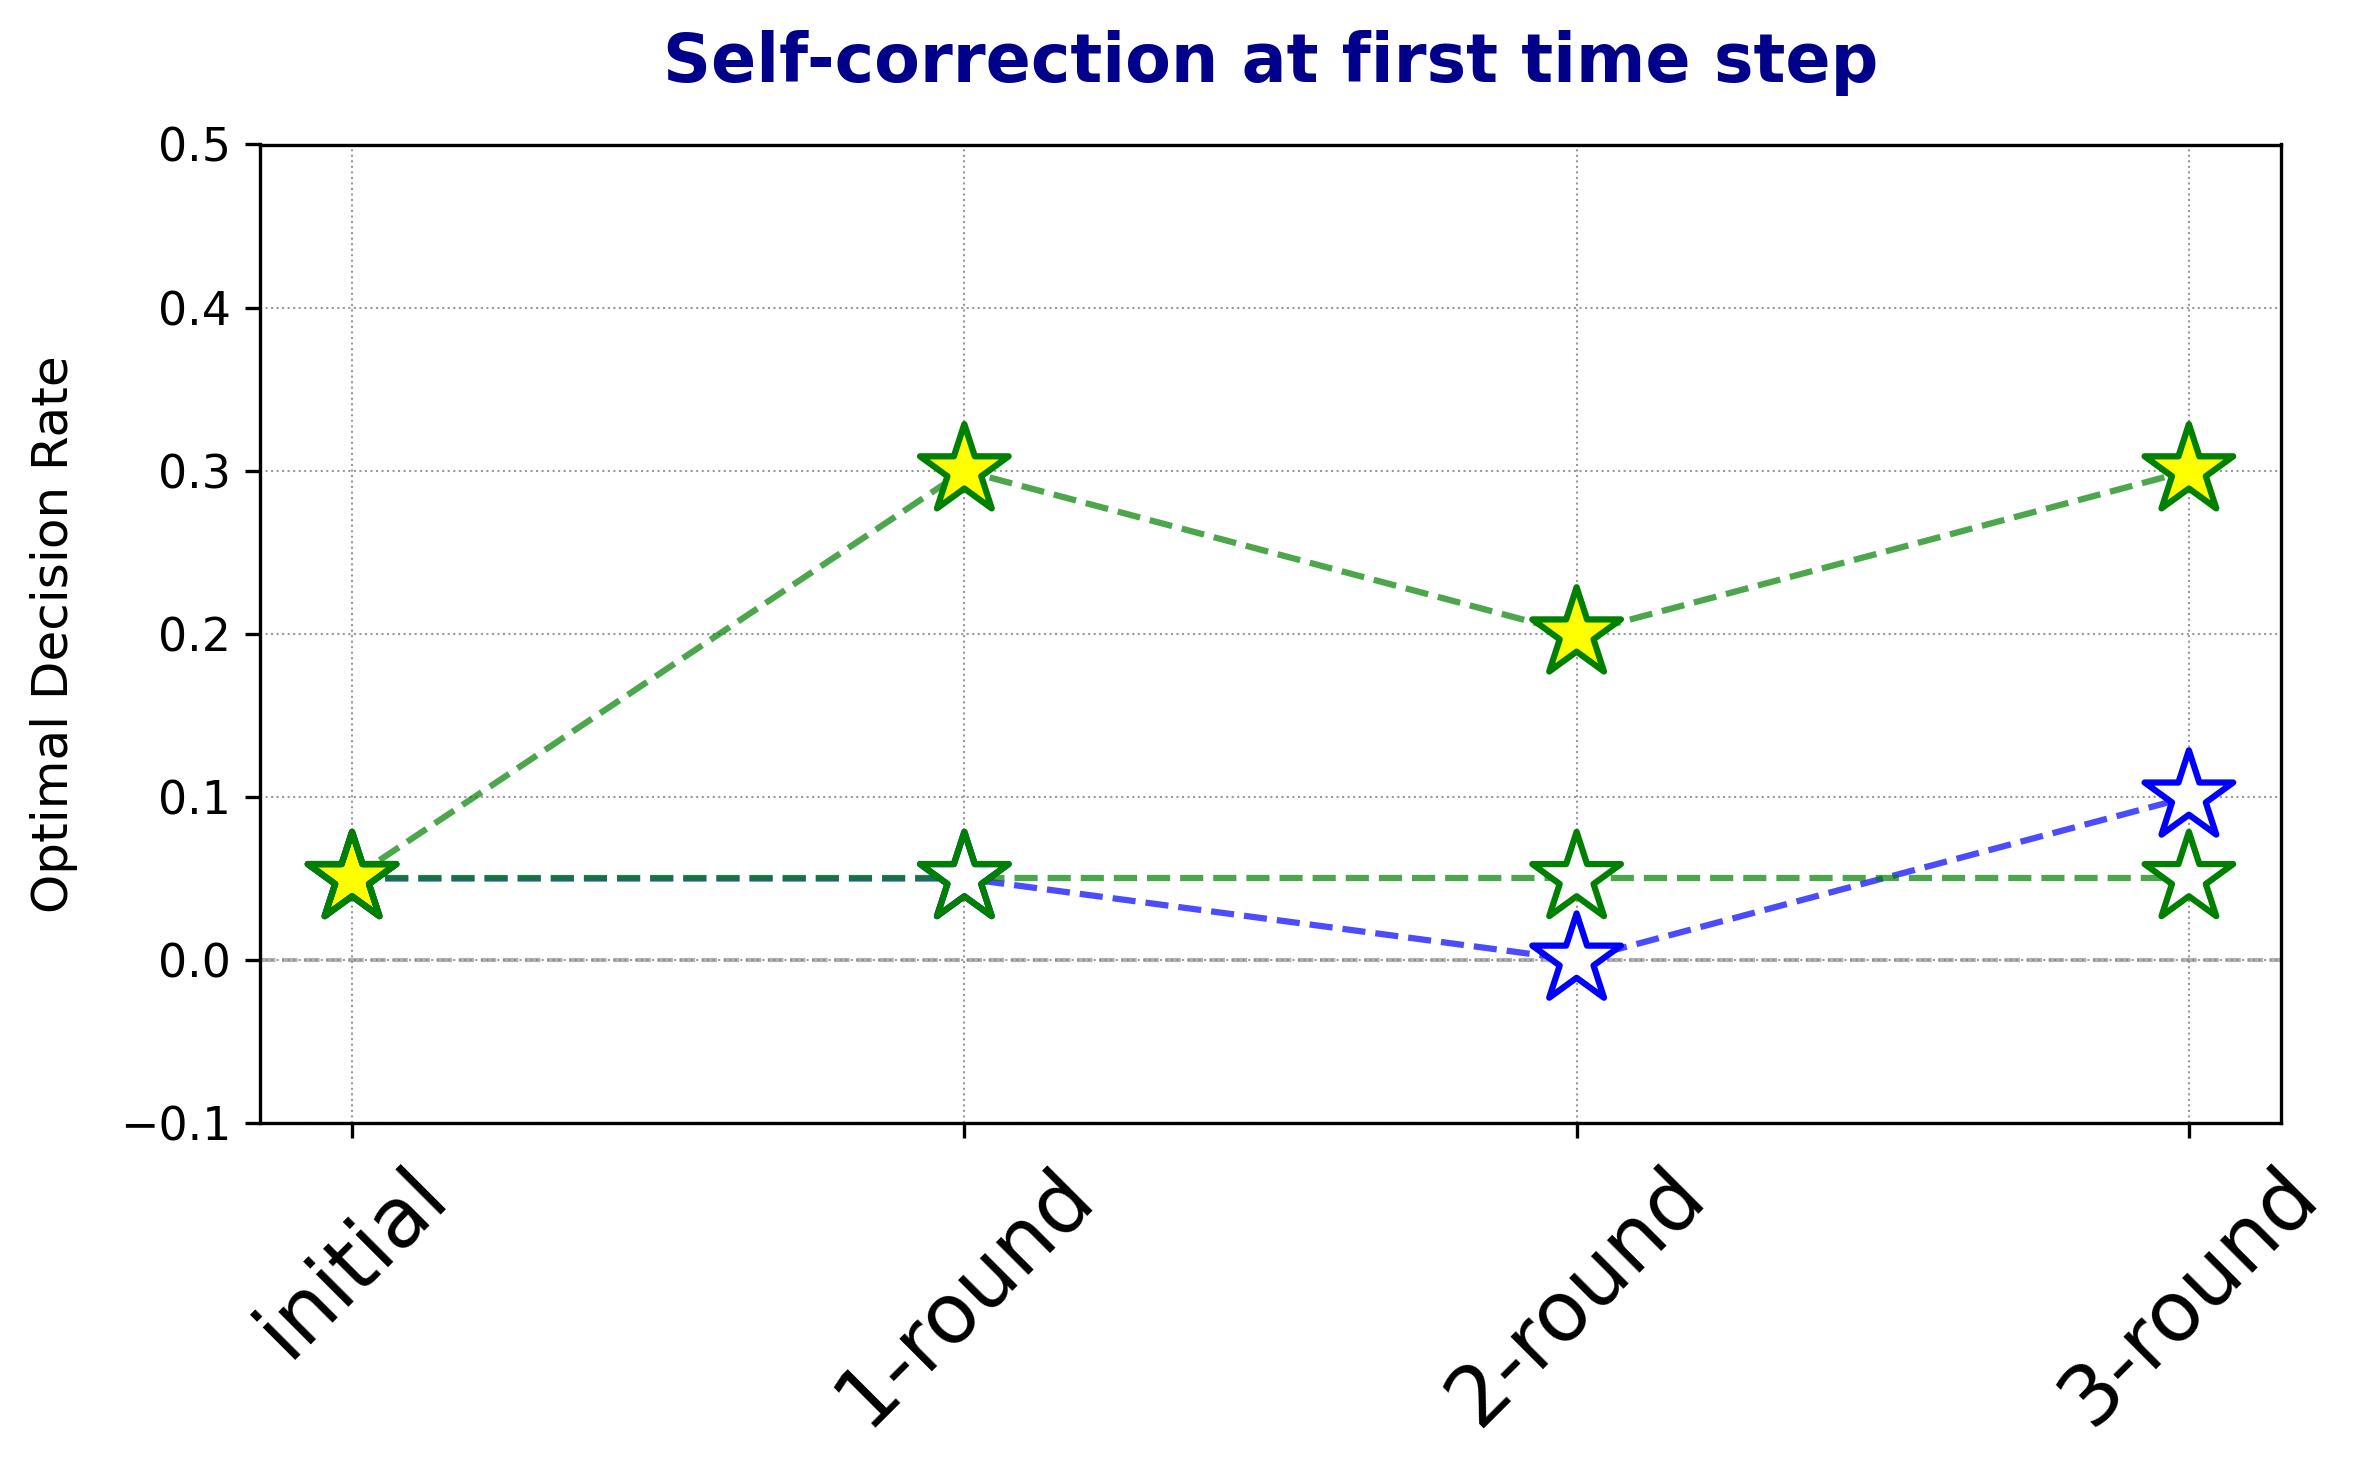

In [80]:
import matplotlib.pyplot as plt

# 샘플 데이터
x = ['initial', '1-round', '2-round', '3-round']
y = [0.05, 0.05, 0.0, 0.1]
z = [0.05, 0.05, 0.05, 0.05]
k = [0.05, 0.30, 0.20, 0.30]

# 그래프 설정
plt.figure(figsize=(8, 5), dpi=300)  # Larger figure size for better visibility

# 데이터 포인트 및 연결선
plt.plot(x, y, linestyle='--', color='blue', linewidth=1.5, alpha=0.7)  # Dashed line for style
plt.plot(x, z, linestyle='--', color='green', linewidth=1.5, alpha=0.7)  # Dashed line for style
plt.plot(x, k, linestyle='--', color='green', linewidth=1.5, alpha=0.7)  # Dashed line for style

# 데이터 포인트 (하얀색 채우기 + 초록색 외곽선)
for xi, yi in zip(x, y):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='white', edgecolors='none', s=500, zorder=3, 
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='blue', s=500, linewidths=1.5, zorder=4,
    )

for xi, yi in zip(x, z):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='white', edgecolors='none', s=500, zorder=3, 
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='green', s=500, linewidths=1.5, zorder=4,
    )

for xi, yi in zip(x, k):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='yellow', edgecolors='none', s=500, zorder=3, 
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='green', s=500, linewidths=1.5, zorder=4,
    )

# 강조 요소
# for i, val in enumerate(y):
#     plt.text(x[i], val - 0.04, f"{val:.2f}", color='green', ha='center', fontsize=10)  # Annotate values
# for i, val in enumerate(z):
#     plt.text(x[i], val + 0.04, f"{val:.2f}", color='blue', ha='center', fontsize=10)  # Annotate values

# 스타일 개선
plt.title("Self-correction at first time step", fontsize=16, fontweight='bold', color='darkblue', pad=15)
# plt.xlabel("# of Refinement", fontsize=12, labelpad=10)
plt.ylabel("Optimal Decision Rate", fontsize=12, labelpad=10)
plt.ylim(-0.1, 0.5)
plt.xticks(fontsize=20, rotation=45)
plt.yticks(fontsize=11)
plt.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.8)  # Light, dotted gridlines
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)  # Highlight x-axis baseline

# 범례 및 출력
plt.legend(loc='upper left', fontsize=10, frameon=False)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

/tmp/ipykernel_3671437/1355142439.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=10, frameon=False)


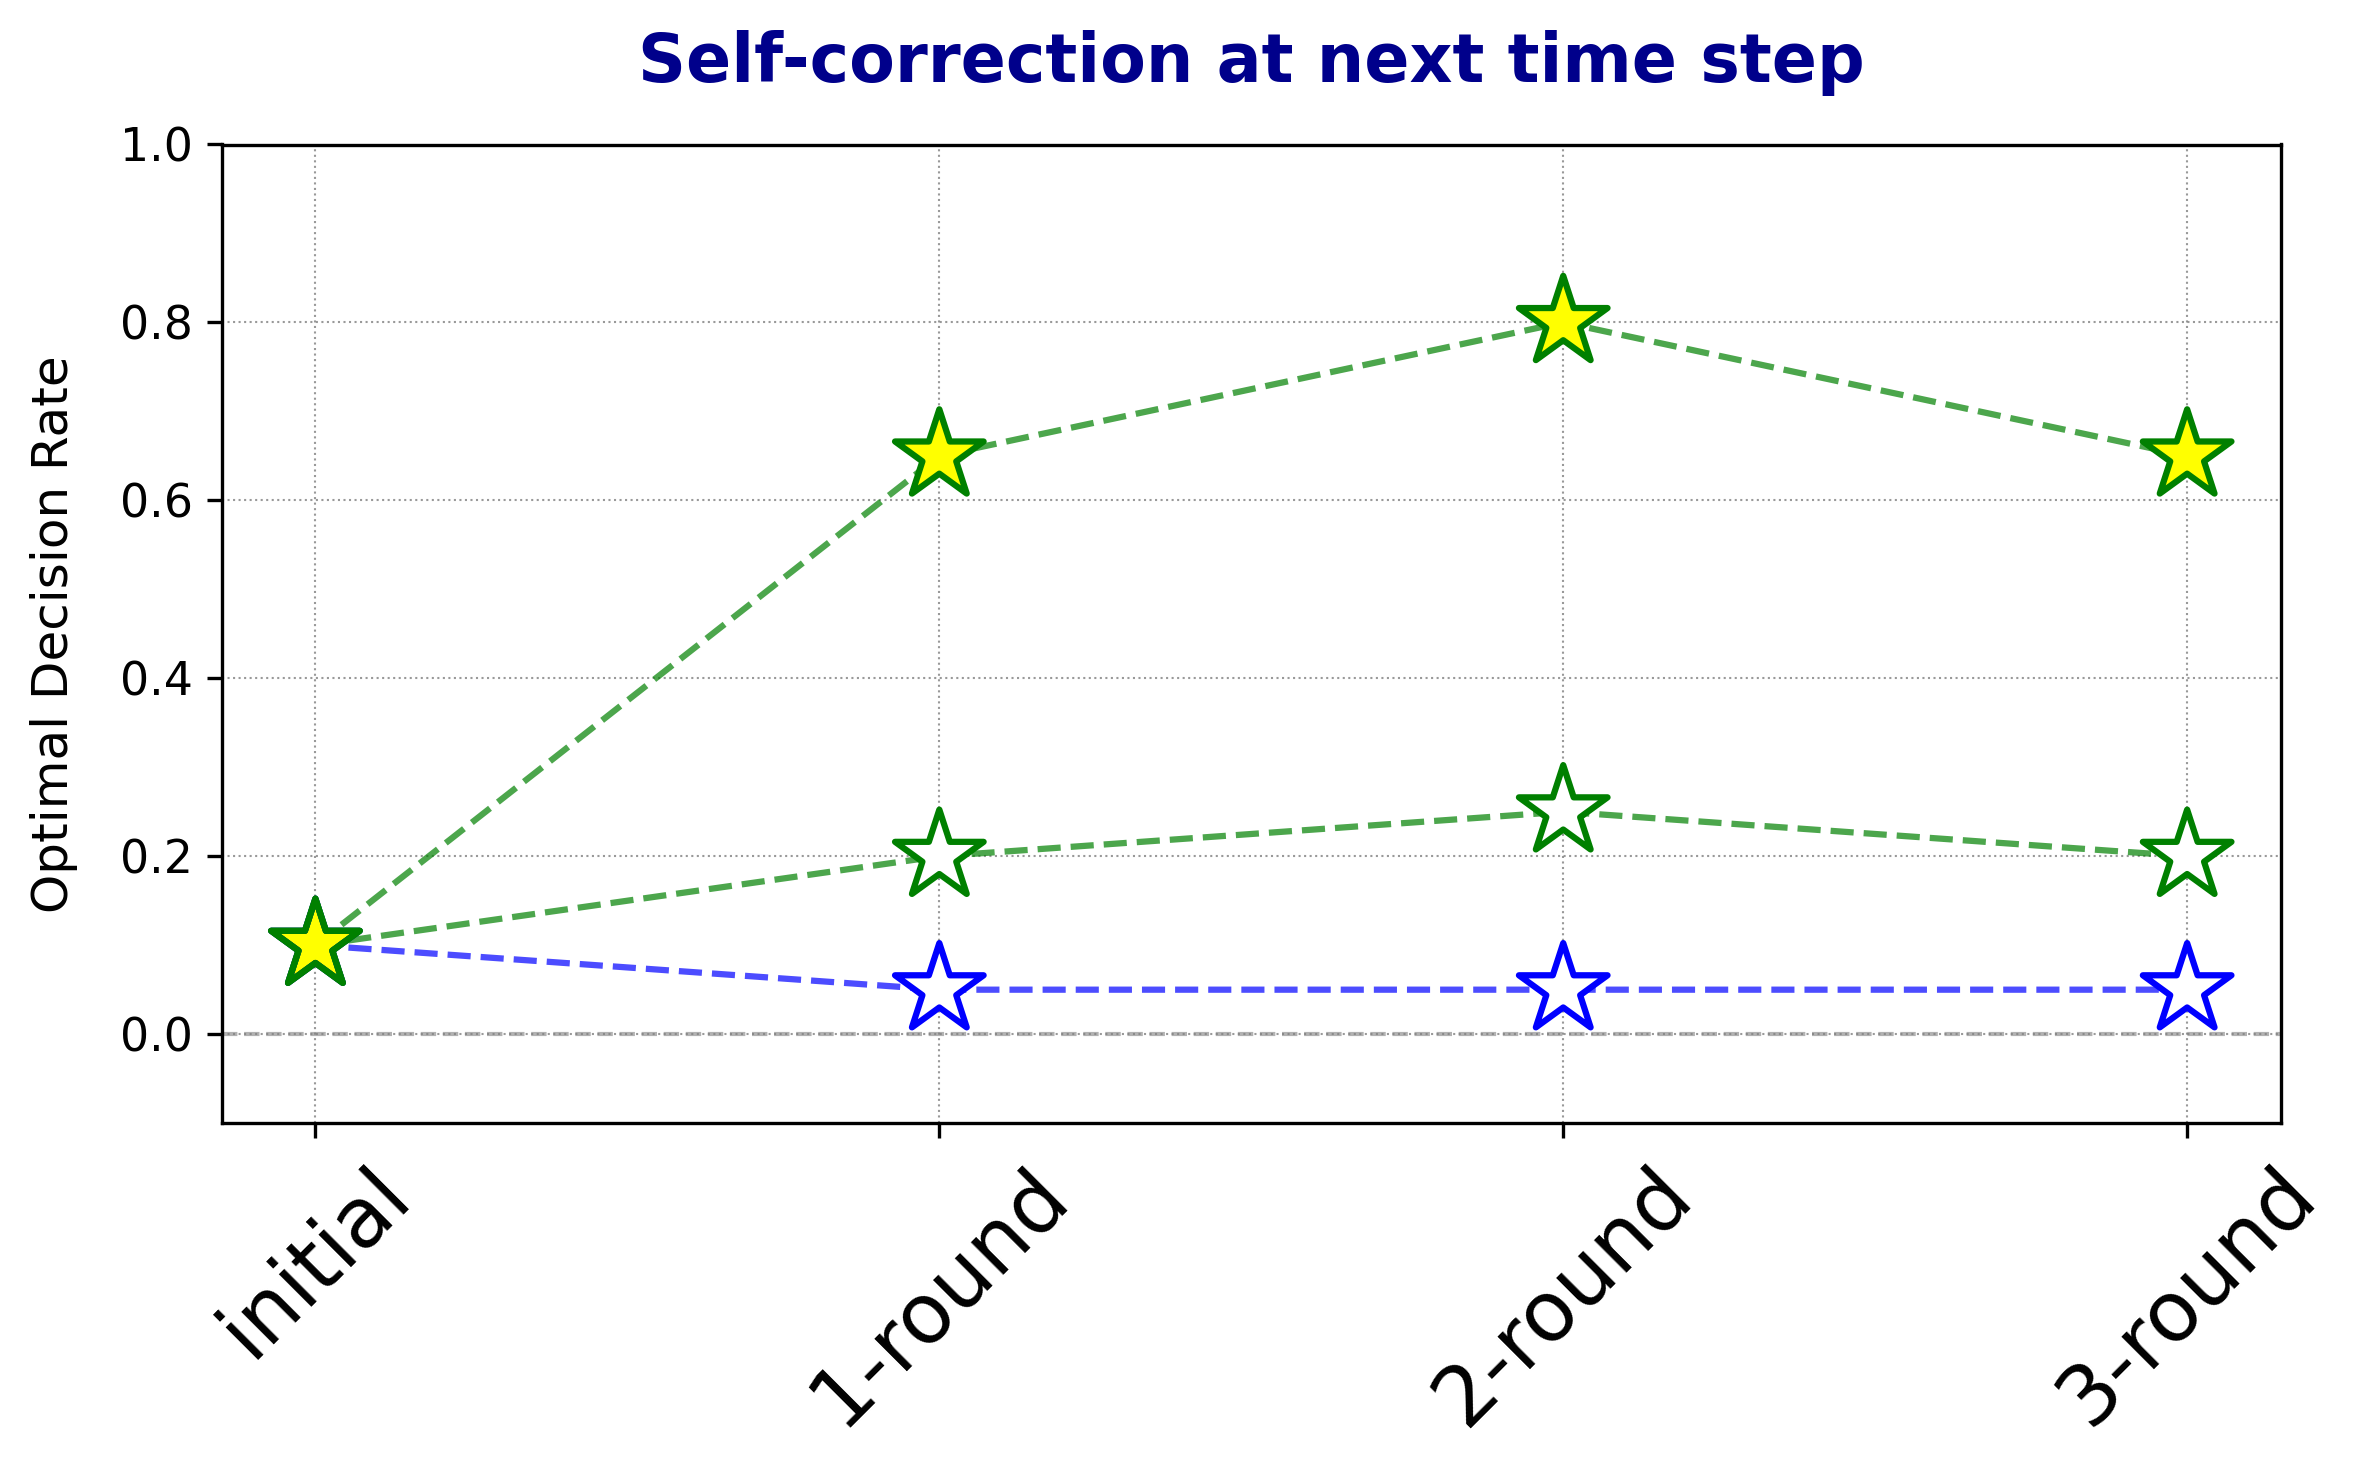

In [82]:


import matplotlib.pyplot as plt

# 샘플 데이터
x = ['initial', '1-round', '2-round', '3-round']
y = [0.10, 0.05, 0.05, 0.05]
z = [0.10, 0.20, 0.25, 0.20]
k = [0.10, 0.65, 0.80, 0.65]

# 그래프 설정
plt.figure(figsize=(8, 5), dpi=300)  # Larger figure size for better visibility

# 데이터 포인트 및 연결선
plt.plot(x, y, linestyle='--', color='blue', linewidth=1.5, alpha=0.7)  # Dashed line for style
plt.plot(x, z, linestyle='--', color='green', linewidth=1.5, alpha=0.7)  # Dashed line for style
plt.plot(x, k, linestyle='--', color='green', linewidth=1.5, alpha=0.7)  # Dashed line for style

# 데이터 포인트 (하얀색 채우기 + 초록색 외곽선)
for xi, yi in zip(x, y):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='white', edgecolors='none', s=500, zorder=3, 
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='blue', s=500, linewidths=1.5, zorder=4,
    )

for xi, yi in zip(x, z):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='white', edgecolors='none', s=500, zorder=3, 
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='green', s=500, linewidths=1.5, zorder=4,
    )

for xi, yi in zip(x, k):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='yellow', edgecolors='none', s=500, zorder=3, 
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='green', s=500, linewidths=1.5, zorder=4,
    )

# 강조 요소
# for i, val in enumerate(y):
#     plt.text(x[i], val - 0.04, f"{val:.2f}", color='green', ha='center', fontsize=10)  # Annotate values
# for i, val in enumerate(z):
#     plt.text(x[i], val + 0.04, f"{val:.2f}", color='blue', ha='center', fontsize=10)  # Annotate values

# 스타일 개선
plt.title("Self-correction at next time step", fontsize=16, fontweight='bold', color='darkblue', pad=15)
# plt.xlabel("# of Refinement", fontsize=12, labelpad=10)
plt.ylabel("Optimal Decision Rate", fontsize=12, labelpad=10)
plt.ylim(-0.1, 1.0)
plt.xticks(fontsize=20, rotation=45)
plt.yticks(fontsize=11)
plt.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.8)  # Light, dotted gridlines
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)  # Highlight x-axis baseline

# 범례 및 출력
plt.legend(loc='upper left', fontsize=10, frameon=False)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

/tmp/ipykernel_3671437/1765779365.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=10, frameon=False)


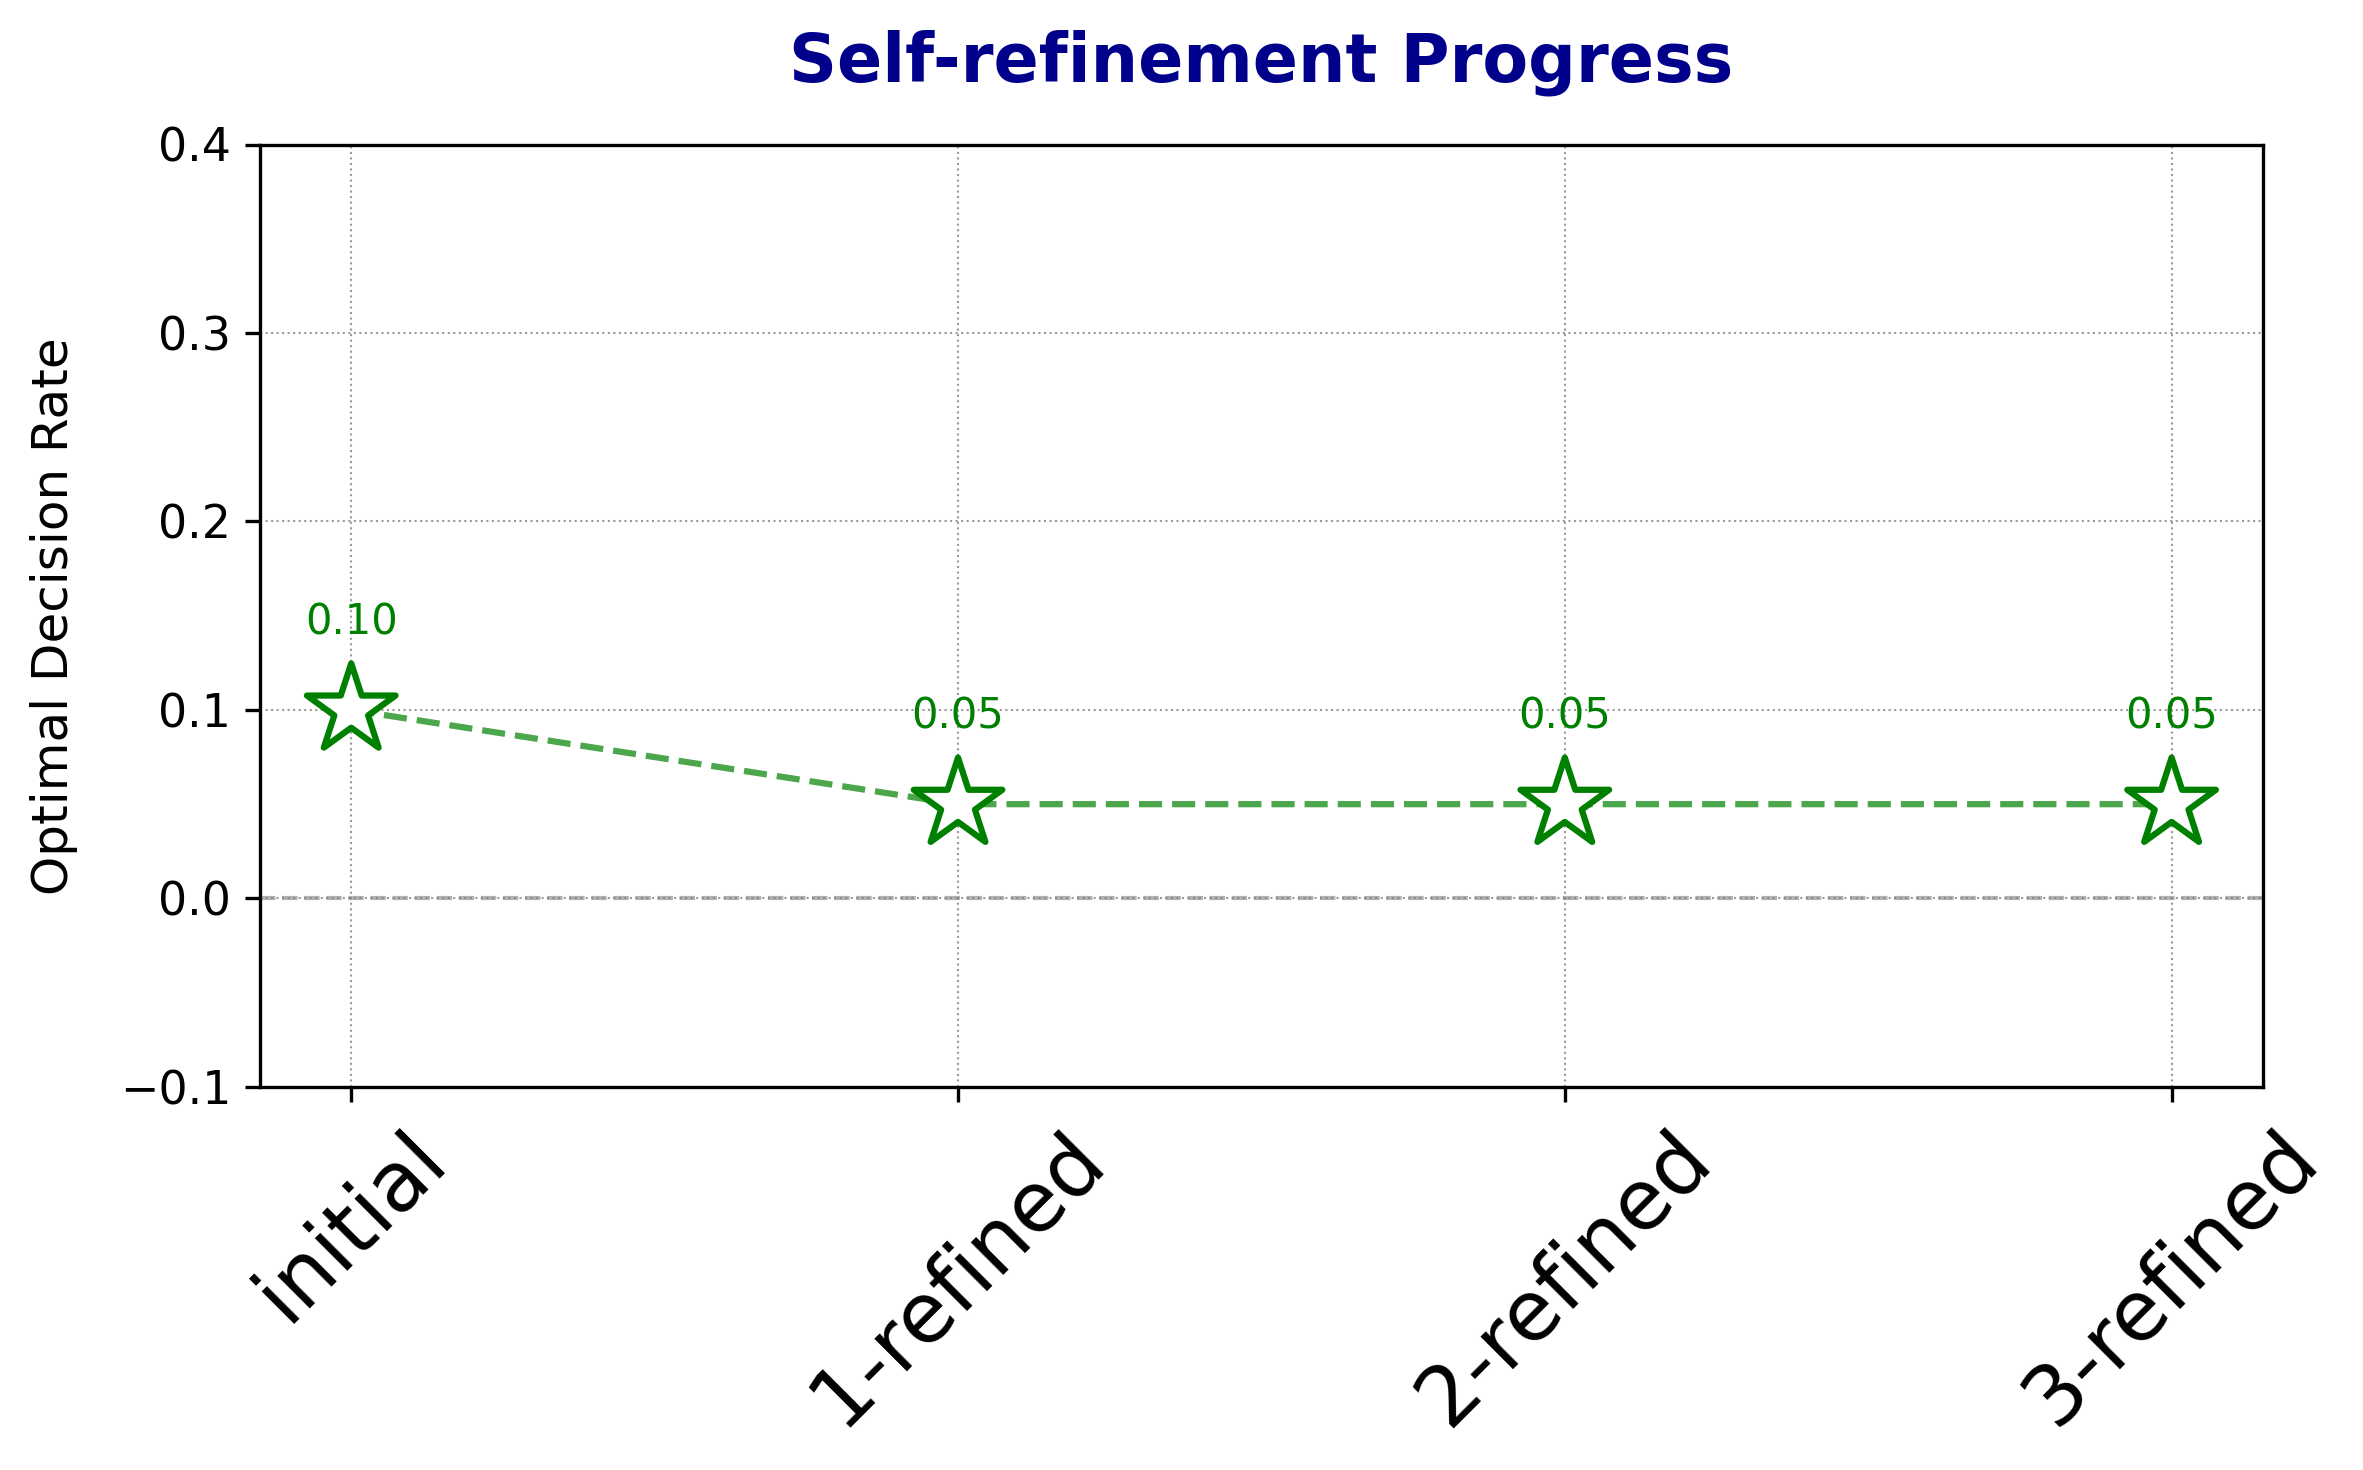

In [24]:
import matplotlib.pyplot as plt

# 샘플 데이터
x = ['initial', '1-refined', '2-refined', '3-refined']
y = [0.1, 0.05, 0.05, 0.05]

# 그래프 설정
plt.figure(figsize=(8, 5), dpi=300)  # Larger figure size for better visibility

# 데이터 포인트 및 연결선
plt.plot(x, y, linestyle='--', color='green', linewidth=1.5, alpha=0.7)  # Dashed line for style

# 데이터 포인트 (하얀색 채우기 + 초록색 외곽선)
for xi, yi in zip(x, y):
    # 하얀색 채워진 별
    plt.scatter(
        [xi], [yi],
        marker='*', color='white', edgecolors='none', s=500, zorder=3
    )
    # 초록색 외곽선 별
    plt.scatter(
        [xi], [yi],
        marker='*', facecolors='none', edgecolors='green', s=500, linewidths=1.5, zorder=4,
    )

# 강조 요소
for i, val in enumerate(y):
    plt.text(x[i], val + 0.04, f"{val:.2f}", color='green', ha='center', fontsize=10)  # Annotate values

# 스타일 개선
plt.title("Self-refinement Progress", fontsize=16, fontweight='bold', color='darkblue', pad=15)
# plt.xlabel("# of Refinement", fontsize=12, labelpad=10)
plt.ylabel("Optimal Decision Rate", fontsize=12, labelpad=10)
plt.ylim(-0.1, 0.4)
plt.xticks(fontsize=20, rotation=45)
plt.yticks(fontsize=11)
plt.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.8)  # Light, dotted gridlines
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)  # Highlight x-axis baseline

# 범례 및 출력
plt.legend(loc='upper left', fontsize=10, frameon=False)
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [61]:
# actions = [6, 5, 6, 5, 5, 5, 5, 13, 5, 5, 9, 5, 6, 8, 3, 5, 5, 5, 13, 1]
# reasonings = [
#     "In order to win the game, I need to leave my opponent in a position where they cannot reach a winning move. Currently, there are 13 stones remaining, and I can take anywhere between 1 and 13 stones. If I take 6 stones, this will leave 7 stones for my opponent. No matter how many stones they take (between 1 and 12, due to the rule of taking at most twice the previous amount), I can adjust my following moves to ensure I take the last stone. Taking 6 stones now is a strategic move to maintain control of the game.",
#     "In the Fibonacci game, the objective is to leave a number of stones that is a Fibonacci number after my turn, giving me a strategic advantage. The Fibonacci numbers up to 13 are 1, 2, 3, 5, 8, 13. The previous player took 7 stones, so I can take between 1 and 13 stones. If I take 5 stones, I will leave 8 stones for the next player, which is a Fibonacci number. This forces the opponent into a suboptimal position, increasing my chances of winning.",
#     "In the current state, there are 13 stones remaining, and I can take between 1 and 13 stones. My goal is to leave my opponent in a position where they cannot win. If I take 6 stones, I'll leave 7 stones remaining, which is the same number my opponent last took. This will put them at a disadvantage because any number they take will allow me to take the last stone on my next turn. Therefore, taking 6 stones is a strategic move to ensure I can win on my next turn.",
#     "To win the Fibonacci game, it's strategic to leave the opponent with a number of stones that is a Fibonacci number, as it makes it harder for them to win. The Fibonacci numbers less than or equal to 13 are 1, 2, 3, 5, 8, and 13. Since the last player took 7 stones, I can take between 1 and 13 stones. If I take 5 stones, 13 - 5 = 8 stones will remain, which is a Fibonacci number. This puts the opponent in a less advantageous position, whereas taking 8 stones would leave 5 remaining, another Fibonacci number. Thus, taking 5 stones is a strategic choice.",
#     "In the Fibonacci game, my goal is to leave my opponent in a position where they cannot win on their next turn. The key is to analyze the remaining stones and ensure that I maximize my chances of being the player to take the last stone. With 13 stones remaining, if I take 5 stones, I leave 8 stones for my opponent. This puts my opponent in a more challenging position, as they can take between 1 and 10 stones on their next turn, regardless of what they choose, I should be able to adjust my strategy on my following turn to win.",
#     "To win the game, I need to leave my opponent in a position where they cannot take all the remaining stones on their next turn. Since there are 13 stones left, I can take 5 stones, leaving 8 stones. This way, no matter how many stones my opponent takes (between 1 and 10), I can always take the remaining stones on my next turn and win.",
#     "With 13 stones remaining, I can take between 1 and 13 stones. To maximize my chances of winning, I should aim to leave a number of stones that is a Fibonacci number for my opponent's turn, as this often forces them into a losing position. The closest Fibonacci numbers less than 13 are 8, 5, 3, and 1. To leave 8 stones, I would take 5 stones (13 - 8 = 5). This action forces my opponent into a position where they cannot leave me another Fibonacci number, thus increasing my chances of winning.",
#     "The objective is to take the last stone. Currently, there are 13 stones remaining, and the last player took 7 stones. I can take up to 13 stones this turn. If I take 13 stones now, I will take all the remaining stones and win the game immediately. Thus, taking 13 stones is the optimal move to ensure victory.",
#     "To maximize my chances of winning, I need to leave the opponent in a position where they cannot take the last stone on their next turn. If I take 5 stones, 8 stones will remain in the pile. This setup allows me to potentially win on my subsequent turn, as my opponent cannot take all 8 stones (they can take between 1 and 10 stones), and I can ensure taking the last stone on my next move.",
#     "In a Fibonacci game, the goal is to leave an unfavorable position for the opponent. An unfavorable position is one where no matter how many stones they take, you can always respond in a way that eventually leaves them with no winning move. The current pile has 13 stones. The last player took 7 stones, so I can take between 1 and 13 stones. To create an unfavorable position for my opponent, I want to leave them with a number of stones that is a Fibonacci number. The Fibonacci numbers up to 13 are 1, 2, 3, 5, 8, and 13. To leave my opponent with a Fibonacci number of stones, I should take 5 stones, leaving them with 8 stones, which is a Fibonacci number.",
#     "To win the game, I need to reduce the number of stones in such a way that my opponent cannot win on their next move. With 13 stones remaining and the ability to take between 1 and 13 stones, I want to ensure that the resulting number of stones left is a multiple of 3 plus 1 (i.e., 4, 7, 10, etc.), which is a losing position for my opponent. This will force my opponent into a position where no matter how many stones they take, they will leave a winning amount for me. Currently, I can take 9 stones to leave exactly 4 stones, forcing my opponent to lose in their next move.",
#     "Currently, there are 13 stones remaining, and the last player took 7 stones. According to the rules, I can take between 1 and 13 stones. To win the game, I need to leave my opponent in a position where they cannot win. The key is to maximize my chances by taking a strategic number of stones. By taking 5 stones, I will leave 8 stones for my opponent. This is a good move because the maximum they can take on their next turn is 10 (2 times the 5 I took), but since there are only 8 stones left, they will be forced to take all of them, and I will win the game by taking the last stone.",
#     "To maximize my chances of winning, I need to ensure that I leave my opponent with a number of stones that is disadvantageous for them. Since the pile has 13 stones left, if I take 6 stones, I will leave 7 stones for my opponent. This way, regardless of how many stones they take (between 1 and 12), I can always take the remaining stones on the next turn, ensuring I win the game.",
#     "In this turn, my goal is to leave my opponent in a position where they cannot leave me in a losing position in their next turn. The optimal strategy in such games is to ensure the number of stones remaining is a number in the Fibonacci sequence after my turn, as this often forces the opponent into a disadvantageous position. The closest Fibonacci numbers to 13 are 8 and 5. Since 13 - 8 = 5 is within my allowed range of 1 to 13, I will take 8 stones, leaving 5 stones for my opponent. This strategically limits their options and increases my chances of winning.",
#     "The goal is to leave the opponent in a losing position by forcing them to face a situation where every move they make will eventually lead to losing. Assuming optimal play from both sides, I aim to leave a number of stones that is not a Fibonacci number, because losing positions in this game are Fibonacci numbers. The Fibonacci sequence up to 13 is 1, 2, 3, 5, 8, and 13. Since 13 is a Fibonacci number, I should try to leave the next player with a non-Fibonacci number. By taking 3 stones, I leave 10 stones, which is not a Fibonacci number and will make it difficult for the opponent to win if they do not play perfectly.",
#     "To maximize my chances of winning, I need to strategize based on the number of stones left and the rules of the game. Since there are 13 stones remaining and the last player took 7 stones, I can take any number between 1 and 13 stones. The strategy is to leave the opponent with a number of stones that is a Fibonacci number, which forces them into a losing position if they don't play optimally. The largest Fibonacci number less than 13 is 8. If I take 5 stones, I will leave 8 stones for my opponent, potentially putting them in a difficult position if they don't play optimally. Thus, I will take 5 stones.",
#     "To maximize my chances of winning, I need to ensure that the number of stones left for my opponent is a losing position if possible. A known strategy in combinatorial games is to force the opponent into a position where they cannot win. In this case, I want to leave a number of stones that is a Fibonacci number, as this generally gives a better chance of control in this specific type of game by creating losing positions for the opponent. The closest Fibonacci numbers less than 13 are 8 and 5. If I take 5 stones, 13 - 5 = 8, leaving my opponent with a Fibonacci number, which is a losing position. Therefore, my optimal move is to take 5 stones.",
#     "To maximize my chances of winning, I need to consider the number of stones left after my turn. The goal is to leave my opponent in a position where they can't leave me a winning move. With 13 stones remaining, if I take 5 stones, there will be 8 stones left. My opponent can then take between 1 and 10 stones. No matter what they take, I can always take the remaining stones on my next turn to win. Therefore, taking 5 stones is a strategic move that sets me up for a win.",
#     "In the Fibonacci game, one effective strategy is to leave the opponent with a number of stones that is a Fibonacci number. The Fibonacci sequence in this context starts with 1, 1, 2, 3, 5, 8, 13, etc. The current pile has 13 stones. Taking all 13 stones would win the game since it's allowed to take all remaining stones if they are within the allowable range. Thus, taking 13 stones will allow me to win the game immediately.",
#     "To win the game, I need to leave my opponent in a position where they cannot make a winning move. The key is to control the number of stones left in such a way that I can eventually force a win. With 13 stones remaining, the only way to guarantee a win is to leave a number of stones that is a multiple of 3. If I take 1 stone, 12 stones remain, which is a multiple of 3, forcing my opponent into a losing position since they will not be able to take the last stone in their subsequent turn."
# ]
actions = [13, 6, 6, 5, 6, 5, 5, 5, 13, 5, 5, 3, 5, 6, 5, 13, 1, 1, 6, 8]
reasonings = [
    "To win the game, I need to take the last stone. Since there are 13 stones remaining and the previous player took 7 stones, I can take up to 13 stones. By taking all 13 stones, I will leave no stones for my opponent, thus winning the game immediately.",
    "In this turn, I can take between 1 and 13 stones. To win, I should aim to leave the opponent with a number of stones that is unfavorable for them. In this case, if I take 6 stones, I leave 7 stones in the pile, which is a winning position for me. This is because no matter how many stones they take (between 1 and 12), I can always ensure that I take the last stone on my subsequent turn.",
    "To maximize my chances of winning, I need to leave my opponent in a losing position. A losing position in the Fibonacci game occurs when the remaining stones are a Fibonacci number, as the opponent will not be able to force a win from that state. Given there are 13 stones remaining, which is a Fibonacci number, I cannot immediately force a win by leaving them in such a position. Thus, I need to plan my moves carefully. If I take 6 stones, 7 stones will remain, which is not a Fibonacci number. On their turn, my opponent can take between 1 and 12 stones, and whatever they take, I will then have a winning response. Therefore, I will take 6 stones to set myself up for a future win.",
    "In this turn, I want to ensure that I leave my opponent with a number of stones that puts me in a winning position. The Fibonacci sequence involves choosing a number of stones such that I can control the game. With 13 stones remaining, if I take 5 stones, there will be 8 stones left. This is a strategic move because 8 is a number that gives me control over the game and limits my opponent's next move. If they take stones from 1 to 10 (as double of 5 is 10), I will then be able to respond strategically to ensure I take the last stone. Therefore, taking 5 stones gives me the best chance to secure a win.",
    "In order to win the game, I need to ensure that the number of stones left for the opponent is a losing position. A losing position is a position where any move the opponent makes will leave me in a winning position. In this scenario, I can take 6 stones, leaving 7 stones for the opponent. With 7 stones left, my opponent will not be able to take all the stones and leave me with an unavoidable winning move next turn.",
    "To maximize my chances of winning the game, I need to consider the potential responses from my opponent and aim to leave them in a disadvantaged position. With 13 stones remaining and having the ability to take between 1 and 13 stones, I should aim to take a number that leaves a non-winning position for my opponent if possible. A winning strategy in such games often involves leaving a multiple of some strategic number. Here, taking 5 stones would leave 8 stones in the pile for my opponent, which is a non-winning position because in the next turn, the opponent will be forced to leave a total that is not easily navigated to a winning configuration. This strategic choice maximizes potential for my success and ensures I am playing optimally according to the rules and current game state.",
    "To maximize my chances of winning, I should aim to leave a number of stones that is a Fibonacci number for my opponent, because in the Fibonacci game, having control over the Fibonacci numbers can often lead to a winning strategy. The Fibonacci numbers are 1, 2, 3, 5, 8, 13, etc. The current pile has 13 stones, and the last player took 7 stones. I can take up to 13 stones. If I take all 13 stones, I win immediately, which is not allowed. If I leave a Fibonacci number for my opponent, I should take 5 stones, leaving 8 stones, which is a Fibonacci number. This forces my opponent into a difficult position where they have to break from the Fibonacci sequence on their subsequent move.",
    "The goal is to leave the opponent in a position where they cannot win. One way to ensure this is to leave a number of stones that is unfavorable for the opponent. Ideally, I would want to leave the opponent with a number of stones that is a Fibonacci number, as this tends to limit their options effectively. The Fibonacci numbers closest to 13 are 8 and 5. If I take 5 stones, I leave the opponent with 8 stones, which allows me to control the game further. Hence, taking 5 stones will put me in a stronger position to win in subsequent turns.",
    "To ensure a winning strategy in the Fibonacci game, it's important to leave the opponent with a number of stones that is part of the Fibonacci sequence after your turn. The Fibonacci sequence relevant to this game is 1, 2, 3, 5, 8, 13, etc. Currently, there are 13 stones, and I can take up to 13 stones. If I take all 13 stones, I win immediately because there will be no stones left for the opponent. Therefore, the best move is to take all 13 stones.",
    "To ensure a win in the Fibonacci game, I need to leave a position where my opponent cannot make a winning move. Currently, there are 13 stones remaining, and the last player took 7 stones, allowing me to take between 1 and 13 stones. A winning strategy involves leaving a pile that is a Fibonacci number after my move. The Fibonacci numbers less than or equal to 13 are 1, 2, 3, 5, 8, and 13. By taking 5 stones, I leave 8 stones, which is a Fibonacci number. This forces my opponent into a less advantageous position, as they cannot leave me with another Fibonacci number pile on their turn.",
    "To maximize my chances of winning, I should aim to leave a number of stones that is a Fibonacci number after my turn. Fibonacci numbers are advantageous in this game because they often limit the opponent's ability to move optimally. The closest Fibonacci numbers less than 13 are 8, 5, 3, and 1. I can leave 8 stones by taking 5 stones (13 - 5 = 8). This forces the opponent into a less advantageous position, as they will not be able to take all remaining stones on their next turn.",
    "To maximize my chances of winning, I need to leave a non-winning position for my opponent. The winning positions in a Fibonacci game are the positions where the number of stones left is a Fibonacci number. The Fibonacci numbers closest to 13 are 8 and 5. If I take 5 stones, I will leave 8 stones for my opponent, which is a winning position for them. Therefore, I should take 3 stones to leave 10 stones for my opponent. This is not a Fibonacci number, and it forces my opponent into a position where they cannot win immediately on their next turn.",
    "To win the game by taking the last stone, I need to leave my opponent in a position where they cannot avoid leaving stones for me to win in the subsequent turns. Currently, there are 13 stones remaining, and I can take between 1 and 13 stones. If I take 5 stones, 8 stones will remain. This will force my opponent to take between 1 and 10 stones on their next turn. Regardless of their move, I will be able to take the remaining stones on my following turn and win the game.",
    "To win the game, I need to ensure that I leave my opponent with a number of stones that puts them at a disadvantage. If I take 6 stones, I will leave my opponent with 7 stones, which is a Fibonacci number. This will allow me to control the game and eventually take the last stone, as taking stones off a Fibonacci number pile can be disadvantageous for the opponent.",
    "To win the game, I need to leave my opponent in a position where they cannot make a move that allows them to win on their next turn. With 13 stones remaining, I can take 5 stones, leaving 8 stones for my opponent. This is a strategic move because no matter how many stones (1 to 10) my opponent takes, I can always respond in a way that eventually leaves them with no winning move.",
    "To win the game, I need to leave my opponent in a position where they cannot leave me with a winning move. The current pile has 13 stones, and I can take between 1 and 13 stones. Since my opponent took 7 stones, the maximum I can take is 13 stones. Since there are 13 stones remaining and taking all 13 stones ends the game in my favor, I should take all 13 stones to win.",
    "The goal in this game is to leave the opponent in a position where they cannot win if you play optimally from that point onwards. A strategic way to play is to leave the opponent with a number of stones that is one more than a Fibonacci number (1, 2, 3, 5, 8, 13, ...). In this situation, there are 13 stones remaining. 13 is a Fibonacci number itself, and leaving the opponent with 12 stones (13 - 1 = 12) gives them a non-Fibonacci number, which is advantageous for me. Therefore, I will take 1 stone so that the opponent is left with 12 stones.",
    "To maximize my chances of winning, I need to leave the opponent with a number of stones that is a multiple of 3 on their turn. This strategy works because no matter what multiple of 3 the opponent starts with, I can always adjust my move to leave them with another multiple of 3 on their next turn. With 13 stones remaining, I should take 1 stone, leaving 12 stones for the opponent. This is a multiple of 3, and from this point, I can control the game to ensure I take the last stone.",
    "In the Fibonacci game, the goal is to force your opponent into a position where they cannot win, ideally by leaving them with an unfavorable number of stones. Currently, there are 13 stones left, and I can take between 1 and 13 stones. If I take 6 stones, it leaves my opponent with 7 stones. This is an unfavorable position for my opponent because, whatever they take, I will be able to take the remaining stones to win the game. Thus, I will take 6 stones to leave 7 stones for my opponent.",
    "In this turn, I have the opportunity to take between 1 and 13 stones. The optimal strategy in Nim-type games is often to leave the opponent with a number of stones that is a Fibonacci number. The Fibonacci numbers nearest to 13 are 8 and 5. By taking 8 stones, I can leave my opponent with 5 stones, a Fibonacci number, which could potentially limit their options on subsequent turns and give me a strategic advantage."
]

In [73]:
# for section3 at next time step

first_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 13 stones remaining in the pile.\n
The last player took 7 stones.\n
You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}"""
import json
init_answers = []
final_answers = []

first_refined_action = []
first_refined_reasoning = []

sec_refined_action = []
sec_refined_reasoning = []

third_refined_action = []
third_refined_reasoning = []
# for k in range(20):   
#     basic_action = actions[k]
#     initial_reasoning = reasonings[k]
#     ## basic

#     ## self-refinement
#     initial_move = int(basic_action)

#     print('init action:', initial_move)
#     print('init reason:', initial_reasoning)

#     for k in range(3):
        
#         feedback_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
# #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
# #Game Rule:\n 1. There is a single pile of stones.\n
# 2. Players take turns to take stones.\n
# 3. The first player can take any number of stones, but not all the stones in the first move.\n
# 4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
# 5. The player who takes the last stone wins the game.\n\n
# #Current State:\n There are 13 stones remaining in the pile.\n
# The last player took 7 stones.\n
# You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

# #Task:\nYou are the first player. Based on the current state of the game, give a feedback on the first trial's reasoning and action.\n\n
# #First trial's reasoning and action:\nYou initially chose {initial_move} items at first trial by the reason: '{initial_reasoning}'.\n\n
        

#         The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"feedback": string  // This is the feedback for the selected action and reasoning\n}}
#         """

#         while True:
#             try:
#                 response = client.chat.completions.create(
#                     messages=[
#                     {
#                         "role": "system",
#                         "content": "You are a skilled Nim player.",
#                     },
#                     {
#                         "role": "user",
#                         "content": f"{feedback_prompt}",
#                     }
#                 ],
#                 model='gpt-4o',
#                 temperature=0.7
#                 )
#                 content = response.choices[0].message.content
#                 matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#                 parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#                 parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

#                 parsed_content = json.loads(parsed_content_with_braces)
#                 break
#             except (AttributeError, json.JSONDecodeError) as e:
#                 print(f"Error encountered: {e}. Retrying...")
#                 continue  # Retry by calling say_model again
        
#         matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#         parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#         parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#         parsed_content = json.loads(parsed_content_with_braces)

#         feedback = parsed_content.get("feedback")

#         refine_prompt = f"""
#             #Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
#             #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#             #Game Rule:\n 1. There is a single pile of stones.\n
#             2. Players take turns to take stones.\n
#             3. The first player can take any number of stones, but not all the stones in the first move.\n
#             4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
#             5. The player who takes the last stone wins the game.\n\n
#             #Current State:\n There are 13 stones remaining in the pile.\n
#             The last player took 7 stones.\n
#             You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

#             You initially chose {initial_move} items at first trial by the reason: '{initial_reasoning}'.\n\n
#             You recieved feedback on your action and reasoning: {feedback}\n\n

#             #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

#             The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}
#                 """
    
#         while True:
#             try:
#                 response = client.chat.completions.create(
#                 messages=[
#                     {
#                         "role": "system",
#                         "content": "You are a skilled Nim player.",
#                     },
#                     {
#                         "role": "user",
#                         "content": f"{refine_prompt}",
#                     }
#                 ],
#                 model='gpt-4o',
#                 temperature=0.7
#                 )
#                 content = response.choices[0].message.content
#                 matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#                 parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#                 parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

#                 parsed_content = json.loads(parsed_content_with_braces)
#                 break
#             except (AttributeError, json.JSONDecodeError) as e:
#                 print(f"Error encountered: {e}. Retrying...")
#                 continue  # Retry by calling say_model again

#         matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#         parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#         parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#         parsed_content = json.loads(parsed_content_with_braces)

#         refined_reasoning = parsed_content.get("reasoning")
#         refined_action = parsed_content.get("action")

#         if k == 0:
#             first_refined_action.append(refined_action)
#             first_refined_reasoning.append(refined_reasoning)
#         elif k == 1:
#             sec_refined_action.append(refined_action)
#             sec_refined_reasoning.append(refined_reasoning)
#         elif k == 2:
#             third_refined_action.append(refined_action)
#             third_refined_reasoning.append(refined_reasoning)
        
#         print(f'{k+1} refined action:', refined_action)
#         print(f'{k+1} refined reason:', refined_reasoning)


#         initial_move = refined_action
#         initial_reasoning = refined_reasoning

# print('init', Counter(actions))
# print('first', Counter(first_refined_action))
# print('second', Counter(sec_refined_action))
# print('third', Counter(third_refined_action))

    


    ## self-con

    ## debate
total_action = []
for k in range(20):   
    end = False
    print('New start!')
    basic_action = actions[k]
    basic_reasoning = reasonings[k]
    ## debate
    initial_moves = {}
    initial_reasonings = {}
    i = 0
        
    while True:
        try:
            response = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are a skilled game player.",
                },
                {
                    "role": "user",
                    "content": f"{first_prompt}",
                }
            ],
            model='gpt-4o',
            temperature=0.7
            )
            content = response.choices[0].message.content
            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

            parsed_content = json.loads(parsed_content_with_braces)
            break
        except (AttributeError, json.JSONDecodeError) as e:
            print(f"Error encountered: {e}. Retrying...")
            continue  # Retry by calling say_model again

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    others_reasoning = parsed_content.get("reasoning")
    others_action = parsed_content.get("action")
    initial_moves['agent1'] = basic_action
    initial_reasonings['agent1'] = basic_reasoning
    print('initial A1: ', basic_action, basic_reasoning)
    initial_moves['agent2'] = others_action
    initial_reasonings['agent2'] = others_reasoning
    print('initial A2: ', others_action, others_reasoning)
    

    for t in range(3):
        # agent_moves_str = "\n".join(f"{name}: {move}" for name, move in initial_moves.items())
        # refined_moves = {}
        i = 0
        for a in range(2):
            if a == 0:
                prompt = f"""
                #Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
                #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
                #Game Rule:\n 1. There is a single pile of stones.\n
                2. Players take turns to take stones.\n
                3. The first player can take any number of stones, but not all the stones in the first move.\n
                4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
                5. The player who takes the last stone wins the game.\n\n
                #Current State:\n There are 13 stones remaining in the pile.\n
                The last player took 7 stones.\n
                You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

                #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

                You initially chose {initial_moves['agent1']} items at first trial by the reason: '{initial_reasonings['agent1']}'.\n
                Other agent argues that you have to choose move as: {initial_moves['agent2']} by the reason: {initial_reasonings['agent2']}.\n
                Considering the other's opinion, refine or confirm your move.\n

                The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}
                """
            if a == 1:
                prompt = f"""
                #Game Role:\n You are Agent 1, a participant in a simple game.\n\n
                #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
                #Game Rule:\n 1. There is a single pile of stones.\n
                2. Players take turns to take stones.\n
                3. The first player can take any number of stones, but not all the stones in the first move.\n
                4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
                5. The player who takes the last stone wins the game.\n\n
                #Current State:\n There are 13 stones remaining in the pile.\n
                The last player took 7 stones.\n
                You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

                #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

                You initially chose {initial_moves['agent2']} items at first trial by the reason: '{initial_reasonings['agent2']}'.\n
                Other agent argues that you have to choose move as: {initial_moves['agent1']} by the reason: {initial_reasonings['agent1']}.\n
                Considering the other's opinion, refine or confirm your move.\n

                The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}
                """
            
            while True:
                try:
                    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled game player and debating the best move.",
                        },
                        {
                            "role": "user",
                            "content": f"{prompt}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
                    content = response.choices[0].message.content
                    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
                    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
                    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()

                    parsed_content = json.loads(parsed_content_with_braces)
                    break
                except (AttributeError, json.JSONDecodeError) as e:
                    print(f"Error encountered: {e}. Retrying...")
                    continue  # Retry by calling say_model again

            matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

            parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
            parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
            parsed_content = json.loads(parsed_content_with_braces)

            initial_reasoning = parsed_content.get("reasoning")
            initial_action = parsed_content.get("action")
            if a == 0:
                initial_moves['agent1'] = initial_action
                initial_reasonings['agent1'] = initial_reasoning
                print('debate round:, ', t, 'my action: ', initial_action)
                print('debate round:, ', t, 'my reasoning: ', initial_reasoning)    
            if a == 1:
                initial_moves['agent2'] = initial_action
                initial_reasonings['agent2'] = initial_reasoning
                print('debate round:, ', t, 'others action: ', initial_action)
                print('debate round:, ', t, 'others reasoning: ', initial_reasoning)    
            
        i += 1
            # initial_moves[agent["name"]] = initial_action
            # initial_reasonings[agent["name"]] = initial_reasoning

        # initial_moves = refined_moves
        print('init values:', initial_moves.values())
        
    if len(set(initial_moves.values())) == 1:
            print('final Here:', initial_action, initial_reasoning)
            total_action.append(initial_action)
    else:
        action_list = [initial_moves['agent1'], initial_moves['agent2']]
        action_list = random.choice(action_list)
        print('final:', action_list, initial_reasoning)
        total_action.append(action_list)
        # print('final:', Counter(initial_moves.values()).most_common(1)[0][0], initial_reasoning)
print('Real Final: ', Counter(total_action))
    
    ## ours
#     text = first_prompt
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a skilled Nim player.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content
#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     refined_reasoning = parsed_content.get("reasoning")
#     refined_action = parsed_content.get("action")
#     init_answers.append(refined_action)

#     print("initial: ", refined_action, refined_reasoning)
    
#     text = f"""Given the following answer, predict the most likely provable question that led to this response.\n
#     #Answer:\n
#         "reasoning": "{refined_reasoning}",
#         "action": {refined_action}\n\n
#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"provable question": string  // This is a most likely provable question that led to above answer.\n}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are good at predicting something.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content
#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#     #There are two instructions with the same intention but different nuances. Combine them into a single instruction that captures the shared intention while harmonizing the nuances effectively.
#     #Origianl instruction: {first_prompt}\n\n
#     #Bias mitigated instruction: {question}

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     question = parsed_content.get("provable question")

#     text = f"""Combine the following two instructions into a single instruction that captures their shared intention while harmonizing their nuances. Pay attention to clarity and ensure that any biases in the original instructions are mitigated.

# - Original instruction (`{first_prompt}`): The first instruction to consider.
# - Bias-mitigated instruction (`{question}`): The second instruction to harmonize.

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"instruction": string  // This is the combined instruction harmonizing the two instructions.\n\t"reasoning": string  // This is the reason why new instruction is harmonized.}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational smart assistant.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content

#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     new_instruction = parsed_content.get("instruction")

#     print('new instruction', new_instruction)

#     text = f"""{new_instruction}

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational game player.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content

#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     refined_reasoning = parsed_content.get("reasoning")
#     refined_action = parsed_content.get("action")
#     print("Final: ", refined_action, refined_reasoning)
#     final_answers.append(refined_action)

# print('Init: ', init_answers, Counter(init_answers))
# print('Final: ', final_answers, Counter(final_answers))

New start!
initial A1:  13 To win the game, I need to take the last stone. Since there are 13 stones remaining and the previous player took 7 stones, I can take up to 13 stones. By taking all 13 stones, I will leave no stones for my opponent, thus winning the game immediately.
initial A2:  13 To win the game, I need to take all the remaining stones, as the rules allow me to take up to 13 stones on this turn (which is the total number of stones left). By taking all 13 stones, I leave none for my opponent, thereby securing the victory.
debate round:,  0 my action:  13
debate round:,  0 my reasoning:  To win the game, I need to take all the remaining stones. Since there are 13 stones left and I am allowed to take up to 13 stones, taking all 13 stones will leave none for my opponent, thus ensuring my victory. This is the optimal move to secure the win immediately.
debate round:,  0 others action:  13
debate round:,  0 others reasoning:  Both my initial reasoning and the argument presented 

In [60]:
first_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 13 stones remaining in the pile.\n
The last player took 7 stones.\n
You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}"""
import json
init_answers = []
final_answers = []

# first_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
# #Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
# #Game Rule:\n 1. There is a single pile of stones.\n
# 2. Players take turns to take stones.\n
# 3. The first player can take any number of stones, but not all the stones in the first move.\n
# 4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
# 5. The player who takes the last stone wins the game.\n\n
# #Current State:\n There are 20 stones remaining in the pile.\n
# You can take between 1 and 19 stones on your turn. You are the first player.\n\n

# #Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

# The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""

for k in range(20):   
    text = first_prompt
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("initial: ", refined_action, refined_reasoning)
    
#     text = f"""Given the following instruction, rewrite it to minimize bias stemming from strong prior knowledge while preserving its original intent and clarity.\n
#     #Instruction:{first_prompt}\n
        

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"instruction": string  // This is a rewritten instruction to minimize the bias.\n}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational smart assistant.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content
#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
#     #There are two instructions with the same intention but different nuances. Combine them into a single instruction that captures the shared intention while harmonizing the nuances effectively.
#     #Origianl instruction: {first_prompt}\n\n
#     #Bias mitigated instruction: {question}

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     question = parsed_content.get("instruction")

#     text = f"""Combine the following two instructions into a single instruction that captures their shared intention while harmonizing their nuances. Pay attention to clarity and ensure that any biases in the original instructions are mitigated.

# - Original instruction (`{first_prompt}`): The first instruction to consider.
# - Bias-mitigated instruction (`{question}`): The second instruction to harmonize.

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"instruction": string  // This is the combined instruction harmonizing the two instructions.\n\t"reasoning": string  // This is the reason why new instruction is harmonized.}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational smart assistant.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content

#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     new_instruction = parsed_content.get("instruction")

#     print('new instruction: ', new_instruction)

#     text = f"""{new_instruction}

#     The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.}}
#     """
#     response = client.chat.completions.create(
#                     messages=[
#                         {
#                             "role": "system",
#                             "content": "You are a rational game player.",
#                         },
#                         {
#                             "role": "user",
#                             "content": f"{text}",
#                         }
#                     ],
#                     model='gpt-4o',
#                     temperature=0.7
#                     )
#     content = response.choices[0].message.content

#     matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

#     parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
#     parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
#     parsed_content = json.loads(parsed_content_with_braces)

#     refined_reasoning = parsed_content.get("reasoning")
#     refined_action = parsed_content.get("action")
#     print("Final: ", refined_action, refined_reasoning)
#     final_answers.append(refined_action)

print('Init: ', init_answers, Counter(init_answers))
# print('Final: ', final_answers, Counter(final_answers))

initial:  13 To win the game, I need to take the last stone. Since there are 13 stones remaining and the previous player took 7 stones, I can take up to 13 stones. By taking all 13 stones, I will leave no stones for my opponent, thus winning the game immediately.
initial:  6 In this turn, I can take between 1 and 13 stones. To win, I should aim to leave the opponent with a number of stones that is unfavorable for them. In this case, if I take 6 stones, I leave 7 stones in the pile, which is a winning position for me. This is because no matter how many stones they take (between 1 and 12), I can always ensure that I take the last stone on my subsequent turn.
initial:  6 To maximize my chances of winning, I need to leave my opponent in a losing position. A losing position in the Fibonacci game occurs when the remaining stones are a Fibonacci number, as the opponent will not be able to force a win from that state. Given there are 13 stones remaining, which is a Fibonacci number, I cannot i

In [ ]:
import json
init_answers = []
final_answers = []
for k in range(20):   
    text = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 13 stones remaining in the pile.\n
The last player took 7 stones.\n
You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("initial: ", refined_action, refined_reasoning)

    text = f"""Given the following answer, predict the most likely provable question that led to this response.\n
    #Answer:\n
        "reasoning": "{refined_reasoning}",
        "action": {refined_action}\n\n
    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"provable question": string  // This is a most likely provable question that led to above answer.\n}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are good at predicting something.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    question = parsed_content.get("provable question")

    text = f"""{question}

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))

In [18]:
text = """Below is an answer to some question. Considering the answer, predict the question.
#Answer:
	"reasoning": "With 5 items remaining, I want to ensure that I leave a number of items that is disadvantageous to my opponent. By taking 2 items, I leave 3 items in the pile. This means that no matter how many items my opponent takes (1, 2, or 3), I will be able to take the remaining items on my next turn and win the game.",
	"action": 2
"""
response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{text}",
                    }
                ],
                model='gpt-4o',
                temperature=0.7
                )
content = response.choices[0].message.content
print(content)

The question is likely: "In a game of Nim where players can take 1, 2, or 3 items per turn, and there are 5 items remaining, what is the optimal move to ensure a win?"


In [16]:
text = """What is the optimal number of items to take from a pile of 5 items to ensure a winning strategy in a game where players alternately take 1, 2, or 3 items and the player forced to take the last item loses?

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 3.
"""
response = client.chat.completions.create(
                messages=[
                    {
                        "role": "system",
                        "content": "You are a skilled Nim player.",
                    },
                    {
                        "role": "user",
                        "content": f"{text}",
                    }
                ],
                model='gpt-4o',
                temperature=0.7
                )
content = response.choices[0].message.content
print(content)

In this variant of Nim, where the player forced to take the last item loses, the game is often referred to as a "misère" version. The objective is to leave your opponent in a position where they cannot avoid taking the last item.

When facing a pile of 5 items, consider the strategy backward from smaller numbers of items. You want to leave your opponent with a number of items that is a losing position for them.

For small piles, the losing positions are:
- 1 item: Losing (opponent takes the last item)
- 2 items: Winning (you can take 1 item, leaving 1 for your opponent)
- 3 items: Winning (you can take 2 items, leaving 1 for your opponent)
- 4 items: Winning (you can take 3 items, leaving 1 for your opponent)

Therefore, the losing positions in this misère version are when there is just 1 item left.

To leave your opponent in a losing position when you have 5 items, you should take 1 item. This leaves your opponent with 4 items, a winning position for them, but in the misère version, y

In [5]:
# 질문 생성해서 바이어스 없애기
import json
init_answers = []
final_answers = []
for k in range(50):   
    text = f"""#Game Role:
You are Agent 1, a participant in a simple stone-taking game.

#Objective:
Your primary task is to make your first move, considering the game’s rules and the potential outcomes for both players. Your decision should align with your preferred strategy, which could include maximizing your chances of winning or exploring other approaches.

#Game Rule:
	1.	There is a single pile of stones.
	2.	Players take turns to remove stones from the pile.
	3.	On the first move, you can take any number of stones, except all of them.
	4.	On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.
	5.	The player who takes the last stone wins.

#Current State:
There are 20 stones remaining in the pile. You are the first player.

#Task:
Decide how many stones to take on your turn, within the range allowed by the rules, and provide reasoning for your choice.

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

# print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))


Final:  17 As the first player, I want to maximize my chances of winning by controlling the pace of the game. A good initial strategy is to leave a pile that is a power of 3 minus 1 (i.e., 3^n - 1), which allows me to respond optimally to my opponent's moves. The nearest such number less than 25 is 8 (since 3^2 - 1 = 8). Thus, I should take 17 stones, leaving 8 in the pile. This forces my opponent into a less advantageous position, increasing my chances of ultimately taking the last stone and winning the game.
Final:  1 To maximize my chances of winning, I should aim to leave my opponent with a number of stones that puts them at a strategic disadvantage. A common strategy in such games is to leave the opponent with a number of stones that is one more than a multiple of 3, as this can potentially limit their optimal moves in future rounds. Given that there are 25 stones, taking 1 stone would leave my opponent with 24 stones, which is 3 times 8 (a multiple of 3). This strategy could give

In [4]:
# 질문 생성해서 바이어스 없애기
import json
init_answers = []
final_answers = []
for k in range(50):   
    text = f"""#Game Role:
You are Agent 1, a participant in a simple Fibonacci game.

#Objective:
Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.

#Game Rule:
1. There is a single pile of stones.
2. Players take turns to take stones.
3. The first player can take any number of stones, but not all the stones in the first move.
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.
5. The player who takes the last stone wins the game.

#Current State:
There are 20 stones remaining in the pile. You are the first player. You can take between 1 and 19 stones on your turn.

#Task:
Based on the current state of the game, decide how many items you will take (between 1 and 19)

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

# print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))


Final:  7 To maximize my chances of winning, I need to leave a number of stones that is a Fibonacci number after my turn. The Fibonacci numbers relevant here, less than 20, are 1, 2, 3, 5, 8, and 13. If I take 7 stones, I will leave 13 stones, which is a Fibonacci number, increasing the likelihood that I can control the game and win.
Final:  7 To ensure I can control the game and have a higher chance of winning, I need to leave a number of stones that is unfavorable for my opponent. The Fibonacci sequence can help determine such positions. Starting from the initial 20 stones, I note that the nearest lower Fibonacci number is 13. By leaving 13 stones, I put my opponent in a position that isn't a direct multiple of a Fibonacci number, which can lead to mistakes. Therefore, I will take 7 stones, leaving 13 stones for my opponent.
Final:  7 The Fibonacci game involves strategic planning to ensure that I can leave my opponent in a losing position eventually. Given that there are 20 stones, 

In [8]:
# 질문 생성해서 바이어스 없애기
import json
init_answers = []
final_answers = []
for k in range(20):   
    text = f"""#Game Role:
You are Agent 1, a participant in a simple Fibonacci game.

#Objective:
Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.

#Game Rule:
1. There is a single pile of stones.
2. Players take turns to take stones.
3. The first player can take any number of stones, but not all the stones in the first move.
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.
5. The player who takes the last stone wins the game.

#Current State:
There are 20 stones remaining in the pile. You are the first player. You can take between 1 and 19 stones on your turn.

#Task:
Based on the current state of the game, decide how many items you will take (between 1 and 19)

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("initial: ", refined_action, refined_reasoning)

    text = f"""Given the following answer, predict the most likely provable question that led to this response.\n
    #Answer:\n
        "reasoning": "{refined_reasoning}",
        "action": {refined_action}\n\n
    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"provable question": string  // This is a most likely provable question that led to above answer.\n}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are good at predicting something.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    question = parsed_content.get("provable question")
    print('question::', question)
    text = f"""{question}

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))


initial:  1 To maximize my chances of winning, I can use a strategy that leaves my opponent in a position where they can't force a win. In Fibonacci games, it's often advantageous to leave the opponent with a number of stones that's one less than a Fibonacci number. The Fibonacci numbers less than 20 are 1, 2, 3, 5, 8, 13, and 21. Since 20 is not a Fibonacci number, I should aim to leave my opponent with a pile that is one less than the nearest larger Fibonacci number, 21. Therefore, I will take 1 stone, leaving the opponent with 19 stones, which is not a Fibonacci number, and gives me control of the game to react to their move in the subsequent turns.
question:: In a two-player game where players alternately take turns removing stones from a pile, and the winner is the one who takes the last stone, how many stones should I take from a pile of 20 stones to leave my opponent in a losing position, assuming the optimal strategy involves Fibonacci numbers?
Final:  1 The strategy is based o

In [5]:
# for section 3
actions = [7, 7, 7, 7, 7, 7, 7, 6, 2, 7, 7, 7, 7, 7, 7, 8, 1, 7, 7, 7]
reasonings = [
    "In the Fibonacci game, the goal is to leave a number of stones that is a Fibonacci number for the opponent, ensuring they cannot secure the advantage. The Fibonacci sequence closest to but not exceeding 20 is 13 (as the sequence goes 1, 2, 3, 5, 8, 13, 21...). To do this, I should take 7 stones (20 - 13 = 7) to leave the opponent with 13 stones, a Fibonacci number, and thus maintain the advantage.",
    "The game is similar to a Nim game, where the optimal strategy is to force the opponent into a position where they cannot make a winning move. In this variant of the game, I want to leave the opponent with a number of stones that is not a Fibonacci number, as this makes it more difficult for them to win. The Fibonacci numbers below 20 are 1, 2, 3, 5, 8, 13, and 21. Since there are 20 stones, I want to take 7 stones, leaving the opponent with 13 stones, which is a Fibonacci number. This will limit their strategic options and increase my chances of winning.",
    "In this game, the objective is to leave a number of stones that forces the opponent into a losing position. The losing positions are when the pile size is a Fibonacci number, as from these positions, any move allows the opponent to reach another Fibonacci number. The closest Fibonacci number less than 20 is 13. If I take 7 stones (20 - 13 = 7), I will leave my opponent with 13 stones, a losing position. From 13, any move the opponent makes will leave me a position that is not a Fibonacci number, allowing me to continue forcing my opponent into losing positions.",
    "To ensure a winning strategy in a Fibonacci game, I need to force my opponent into a position where they cannot mirror my moves effectively. Starting with 20 stones, the best move is to leave my opponent with a number of stones that is a Fibonacci number. The Fibonacci sequence closest to 20 is 13 (as the sequence is 1, 1, 2, 3, 5, 8, 13, 21...). By taking 7 stones, I leave 13 stones, putting my opponent in a more challenging position to win.",
    "In the Fibonacci game, the strategy is to leave the opponent with a number of stones that is part of the Fibonacci sequence. This restricts their options and increases my chances of winning. The Fibonacci numbers up to 20 are 1, 2, 3, 5, 8, 13, and 21. Since I can't leave exactly 21 stones and 20 is not a Fibonacci number, I'll try to leave a pile of 13 stones, which is the highest Fibonacci number less than 20, giving me a strategic advantage. Therefore, I will take 7 stones (20 - 13 = 7).",
    "To maximize my chances of winning, I should try to leave a number of stones that is a Fibonacci number (like 1, 2, 3, 5, 8, 13, etc.) for my opponent. This will make it difficult for them to win under optimal play. The closest Fibonacci number less than 20 is 13. Therefore, I will take 7 stones (20 - 13 = 7) to leave my opponent with 13 stones, putting me in a stronger position strategically.",
    "To maintain an advantage in this Fibonacci game, it's strategic to aim for a position where the number of stones left is a Fibonacci number. This is because such positions allow for a predictable sequence of moves that can lead to a win. With 20 stones remaining, the closest lower Fibonacci number is 13. Therefore, I should take 7 stones (20 - 13 = 7) to leave my opponent with 13 stones, a Fibonacci number, which will give me a strategic advantage.",
    "In the Fibonacci game, the key is to leave your opponent with a number of stones that is one more than a Fibonacci number, ensuring that you can always respond in a way to bring the game back to another such number on your turn. The Fibonacci numbers less than 20 are 1, 2, 3, 5, 8, and 13. The closest number that is one more than a Fibonacci number is 14 (13 + 1). Therefore, I will take 6 stones, leaving 14 stones for my opponent, which is a favorable position for me.",
    "To ensure a strategic advantage, I aim to leave a number of stones that is one more than a multiple of 3 for my opponent. This strategy works because on his turn, my opponent will always face a situation where no matter how many stones he takes, I can adjust my next move to again leave him with a multiple of 3 plus one. Starting with 20 stones, I will take 2 stones, leaving 18, which is a multiple of 3. From this position, no matter how many stones my opponent takes (1 or 2), I can continue this strategy to eventually win the game.",
    "To maximize my chances of winning, I should aim to leave a number of stones that is a Fibonacci number after my move, because this will force my opponent into a disadvantaged position. The largest Fibonacci number less than 20 is 13. Therefore, I should take 7 stones (20 - 13 = 7) to leave 13 stones for my opponent, putting them in a losing position if I play optimally in subsequent rounds.",
    "To optimize my chances of winning, I should aim to leave my opponent with a number of stones that is a Fibonacci number after my turn. This is because in the Fibonacci game, leaving a Fibonacci number for your opponent often allows you to maintain control and eventually win. With 20 stones remaining, the largest Fibonacci number less than 20 is 13. Therefore, to leave 13 stones after my turn, I will take 7 stones.",
    "In the Fibonacci game, the strategy involves trying to leave the opponent with a number of stones that is a Fibonacci number. This generally gives a higher chance of eventually forcing the opponent into a losing position. The closest Fibonacci numbers to 20 are 13 and 21. Since 21 is greater than 20, it's not possible to leave that. Therefore, I aim to leave the opponent with 13 stones, which means I need to take 7 stones from the pile (20 - 13 = 7). By doing this, I increase my chances of controlling the game and driving it towards a win.",
    "In the Fibonacci game, my objective is to leave a number of stones that is a losing position for my opponent. A losing position in this variant is when the number of stones remaining is a Fibonacci number. The closest Fibonacci numbers less than 20 are 13 and 8. By taking 7 stones now, I leave 13 stones for my opponent, putting them in a losing position, as any move they make will no longer result in a Fibonacci number of stones left for me to work with.",
    "To gain a strategic advantage in the Fibonacci game, I need to make sure my opponent is left with a number of stones that is part of the Fibonacci sequence after my turn. The largest Fibonacci number less than 20 is 13. By taking 7 stones, I leave my opponent with 13 stones, thus positioning myself to respond optimally to any number they choose, as long as I continue to leave Fibonacci numbers after my turns.",
    "In the Fibonacci game, a strategic approach for the first player is to aim to leave the opponent in a position where they cannot leave a winning number of stones after their move. A key strategy involves leaving a total number of stones that is a Fibonacci number, as this often puts the opponent in a difficult position. The first few Fibonacci numbers are 1, 2, 3, 5, 8, 13, 21, etc. From 20 stones, if I leave 13 stones (which is a Fibonacci number), my opponent will have limited options, making it easier for me to regain control of the game. Therefore, I will take 7 stones, leaving 13 stones for my opponent.",
    "The key to winning the Fibonacci game is to control the size of the pile in a way that limits the opponent's options and allows you to take the last stone. A good strategy is to aim to leave the opponent with a number of stones that is one less than a Fibonacci number after your turn. The Fibonacci sequence relevant to this game is 1, 2, 3, 5, 8, 13, 21, etc. The closest Fibonacci number to 20 is 21, so the goal is to leave 13 stones (21 - 8) for the opponent. Therefore, I should take 7 stones (20 - 13 = 7) to reach this position.",
    "To maximize my chances of winning, I want to leave my opponent with a number of stones that is part of the losing positions in the Fibonacci game sequence. A losing position is when the number of stones left is a Fibonacci number minus 1. The Fibonacci sequence up to 20 is 1, 2, 3, 5, 8, 13, 21. The closest Fibonacci number minus one under 20 is 12 (13 - 1). Therefore, I should take 8 stones, leaving my opponent with 12 stones, which is a losing position.",
    "In the Fibonacci game, I want to ensure that I can control the game by leaving my opponent in a position where they cannot win. The strategy involves leaving a number of stones that is a Fibonacci number, as this restricts the opponent's options. The Fibonacci sequence is 1, 2, 3, 5, 8, 13, 21, etc. Given that there are 20 stones, I should take 1 stone, leaving 19 stones in the pile. 19 is not a Fibonacci number, which limits the opponent's ability to control the game effectively.",
    "In order to maximize my chances of winning, I need to aim to leave a number of stones that is a Fibonacci number for my opponent. The Fibonacci numbers that I can aim for, which are less than 20, include 1, 2, 3, 5, 8, and 13. By taking 7 stones, I will leave 13 stones in the pile, which is a Fibonacci number. Leaving a Fibonacci number of stones puts my opponent at a disadvantage because I can always respond in such a way to maintain control in future turns.",
    "To maximize my chances of winning, I should aim to leave a number of stones that forces my opponent into a disadvantageous position. The Fibonacci game strategy often involves leaving piles that are Fibonacci numbers if possible, as these numbers tend to limit the opponent's options effectively. The nearest lower Fibonacci number to 20 is 13 (Fibonacci sequence: 1, 2, 3, 5, 8, 13, ...). By taking 7 stones, I can leave my opponent with 13 stones, which is a Fibonacci number and puts me in a strategically advantageous position."
]

In [ ]:
first_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 13 stones remaining in the pile.\n
The last player took 7 stones.\n
You can take between 1 and 13 stones on your turn, where 13 = min(2 × 7, 13).\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 13) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 13.\n}}"""
import json
init_answers = []
final_answers = []

first_prompt = f"""#Game Role:\n You are Agent 1, a participant in a simple Fibonacci game.\n\n
#Objective:\n Your goal is to win the game by taking all remaining stones on your turn, leaving no items for your opponent. The person who takes the last stones wins.\n\n
#Game Rule:\n 1. There is a single pile of stones.\n
2. Players take turns to take stones.\n
3. The first player can take any number of stones, but not all the stones in the first move.\n
4. On subsequent turns, the number of stones a player can take must be at least 1 and at most twice the number of stones the previous player took.\n
5. The player who takes the last stone wins the game.\n\n
#Current State:\n There are 20 stones remaining in the pile.\n
You can take between 1 and 19 stones on your turn. You are the first player.\n\n

#Task:\nBased on the current state of the game, decide how many items you will take (between 1 and 19) on this turn.\n\n

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.\n}}"""

for k in range(20):   
    text = first_prompt
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a skilled Nim player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    init_answers.append(refined_action)

    print("initial: ", refined_action, refined_reasoning)
    
    text = f"""Given the following instruction, rewrite it to minimize bias stemming from strong prior knowledge while preserving its original intent and clarity.\n
    #Instruction:{first_prompt}\n
        

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"instruction": string  // This is a rewritten instruction to minimize the bias.\n}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are good at predicting something.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content
    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)
    #There are two instructions with the same intention but different nuances. Combine them into a single instruction that captures the shared intention while harmonizing the nuances effectively.
    #Origianl instruction: {first_prompt}\n\n
    #Bias mitigated instruction: {question}

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    question = parsed_content.get("instruction")

    text = f"""Combine the following two instructions into a single instruction that captures their shared intention while harmonizing their nuances. Pay attention to clarity and ensure that any biases in the original instructions are mitigated.

- Original instruction (`{first_prompt}`): The first instruction to consider.
- Bias-mitigated instruction (`{question}`): The second instruction to harmonize.

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"instruction": string  // This is the combined instruction harmonizing the two instructions.\n\t"reasoning": string  // This is the reason why new instruction is harmonized.}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a rational smart assistant.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    new_instruction = parsed_content.get("instruction")

    print('new instruction', new_instruction)

    text = f"""{new_instruction}

    The output should be a markdown code snippet formatted in the following schema, including the leading and trailing \\`\\`\\`json" and "\\`\\`\\`":\n\n```\n{{\n\t"reasoning": string  // This is the reasons for the action\n\t"action": integer  // This is an action you take based on the reasoning. Only provide integer between 1 and 19.}}
    """
    response = client.chat.completions.create(
                    messages=[
                        {
                            "role": "system",
                            "content": "You are a rational game player.",
                        },
                        {
                            "role": "user",
                            "content": f"{text}",
                        }
                    ],
                    model='gpt-4o',
                    temperature=0.7
                    )
    content = response.choices[0].message.content

    matches_with_braces = re.search(r'\{.*?\}', content, re.DOTALL)

    parsed_content_with_braces = matches_with_braces.group(0) if matches_with_braces else None
    parsed_content_with_braces = parsed_content_with_braces.replace('\xa0', '').strip()
    parsed_content = json.loads(parsed_content_with_braces)

    refined_reasoning = parsed_content.get("reasoning")
    refined_action = parsed_content.get("action")
    print("Final: ", refined_action, refined_reasoning)
    final_answers.append(refined_action)

print('Init: ', init_answers, Counter(init_answers))
print('Final: ', final_answers, Counter(final_answers))